#**Title:** Can a match outcome in the Portuguese league be predicted?

#**Course:** Programming for Data Science

#**Date:** May 2025

#**Group:** B7

#**Authors:**

Antonio Crespo - 20242034

Diogo Vicente - 20242048

Frederico Sampaio - 20242049

Pedro Matos - 20242053


---

<font color = '#042F86'>

#**1 - Project Objective and Methodology 🎯** </font>

##**1.1 - Objectives**

- **Analysis and Prediction of Match Outcomes in the Primeira Liga** - The main goal of this project is to predict the outcomes of Santa Clara’s matches during the 2024/2025 season in Portugal’s Primeira Liga. To achieve this, the project will explore historical match and team data obtained from the source Football-Data.org. It aims to identify patterns and correlations between performance metrics.

##**1.2 - Methodology**

- The process begins with collecting statistical data for all teams and matches played throughout the season, extracted from the Football-Data.org API.

- The data is then cleaned and processed to ensure consistency and quality, forming the basis for subsequent analysis. New variables may be created, and irrelevant ones may be dropped. Once the data is fully prepared, a final dataframe containing information for all teams will be ready for further procedures.

- A specific focus is placed on visualizing and analyzing data related to Santa Clara’s performance.

- The final step involves developing a predictive model that estimates the probability of Santa Clara winning, drawing, or losing a given match against any opponent. This model will help assess the team’s chances of success based on historical performance and opponent statistics.

<font color = '#042F86'>

# **2 - Import libraries and data 📚** </font>

We start by **importing** the most commonly used Python libraries for:

- **Data manipulation** (pandas, numpy)

- **Data visualization** (matplotlib, seaborn)

- **Preprocessing and scaling** (sklearn.preprocessing)

- **Date and time handling** (datetime)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
import seaborn.objects as so

We also mount Google Drive to access the dataset stored in a shared folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/My Drive/Projeto Python/raw_primeira_liga.csv'
#pedro - '/content/drive/My Drive/Projeto Python/raw_primeira_liga.csv'
# Fred - '/content/drive/My Drive/Colab Notebooks/Python Project/raw_primeira_liga.csv'
# Toni - '/content/drive/MyDrive/NOVA IMS/Programação 🐍/Projeto Python/raw_primeira_liga.csv'
#Diogo - '/content/drive/MyDrive/raw_primeira_liga-2.csv'

<font color = '#042F86'>

# **3 - Exploratory Data Analysis (EDA) 📖** </font>

##**3.1 - Variables and Distributions**

In this section, we perform an **initial examination** of the data structure and contents to gain a better understanding of the **variables** and **distributions**.

We begin by loading the dataset, which contains **612 rows** and **24 variables**.

In [ ]:
sns.set_style('whitegrid')


In [ ]:
df = pd.read_csv(file_path)
model_df = df.copy() # saving a df that will be used in the future
df

,match_id,utc_date,matchday,attendance,team,formation,home_or_away,winner,duration,full_time_home,...,goal_kicks,offsides,red_cards,yellow_cards,yellow_red_cards,saves,shots,shots_on_goal,shots_off_goal,throw_ins
0,504020,2024-08-09T19:15:00Z,1,38513,Sporting Clube de Portugal,3-4-3,home,HOME_TEAM,REGULAR,3,...,4.0,0.0,0,2,0,0.0,24.0,7.0,12.0,18.0
1,504020,2024-08-09T19:15:00Z,1,38513,Rio Ave FC,3-4-2-1,away,HOME_TEAM,REGULAR,3,...,13.0,0.0,0,2,0,4.0,3.0,1.0,2.0,13.0
2,504016,2024-08-10T14:30:00Z,1,1596,AVS,4-3-3,home,DRAW,REGULAR,1,...,9.0,0.0,0,1,0,0.0,16.0,5.0,10.0,18.0
3,504016,2024-08-10T14:30:00Z,1,1596,CD Nacional,4-3-3,away,DRAW,REGULAR,1,...,14.0,1.0,0,1,0,4.0,5.0,1.0,4.0,17.0
4,504021,2024-08-10T17:00:00Z,1,1142,Casa Pia AC,3-4-3,home,AWAY_TEAM,REGULAR,0,...,3.0,3.0,0,2,0,1.0,13.0,2.0,11.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,503726,2025-05-17T17:00:00Z,34,2247,Moreirense FC,4-2-3-1,away,AWAY_TEAM,REGULAR,0,...,9.0,3.0,0,3,0,3.0,15.0,10.0,4.0,21.0
608,503727,2025-05-17T17:00:00Z,34,2911,FC Arouca,4-2-3-1,home,HOME_TEAM,REGULAR,4,...,12.0,4.0,0,1,0,3.0,12.0,6.0,5.0,21.0
609,503727,2025-05-17T17:00:00Z,34,2911,Boavista FC,4-2-3-1,away,HOME_TEAM,REGULAR,4,...,8.0,1.0,0,2,0,2.0,11.0,4.0,5.0,19.0
610,503728,2025-05-17T17:00:00Z,34,5954,SC Farense,4-1-3-2,home,AWAY_TEAM,REGULAR,1,...,13.0,0.0,0,2,0,5.0,9.0,4.0,4.0,35.0


To help us identify each game we assign the **ID column** as the **index** of the DataFrame.

In [ ]:
df.set_index('match_id', inplace = True)

**Dataset Overview**

**Object (text/date) columns (5):**

utc_date: Match date and time

team: Name of the team

home_or_away: Indicates if the team played home or away

winner: Result of the match (e.g., HOME_TEAM, AWAY_TEAM, DRAW)

duration: Match duration type (e.g., REGULAR)



**Integer column (1):**

matchday: Matchday number (from 1 to 34)



**Float columns (18): Numeric performance statistics, including:**

Match score (full_time_home, full_time_away)

Half-time score

Ball possession (ball_possession)

Corner kicks, fouls, free kicks, goal kicks, offsides

Red/yellow cards

Shots (total, on goal, off goal), saves

Throw-ins


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 612 entries, 504020 to 503728
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   utc_date          612 non-null    object 
 1   matchday          612 non-null    int64  
 2   attendance        612 non-null    int64  
 3   team              612 non-null    object 
 4   formation         612 non-null    object 
 5   home_or_away      612 non-null    object 
 6   winner            612 non-null    object 
 7   duration          612 non-null    object 
 8   full_time_home    612 non-null    int64  
 9   full_time_away    612 non-null    int64  
 10  half_time_home    612 non-null    int64  
 11  half_time_away    612 non-null    int64  
 12  ball_possession   604 non-null    float64
 13  corner_kicks      610 non-null    float64
 14  fouls             610 non-null    float64
 15  free_kicks        610 non-null    float64
 16  goal_kicks        610 non-null    float64

We will now examine the **descriptive statistics** of the **numerical** and **categorical** variables, to help identify potential data quality issues (e.g. outliers, missing values, invalid entries), have a quick overview of how each variable behaves to assist in deciding which variables to drop or transform.

In [ ]:
df.describe()

,matchday,attendance,full_time_home,full_time_away,half_time_home,half_time_away,ball_possession,corner_kicks,fouls,free_kicks,goal_kicks,offsides,red_cards,yellow_cards,yellow_red_cards,saves,shots,shots_on_goal,shots_off_goal,throw_ins
count,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,604.000000,610.000000,610.000000,610.000000,610.000000,610.000000,612.000000,612.000000,612.000000,610.000000,610.000000,610.000000,610.000000,610.000000
mean,17.500000,12417.349673,1.401961,1.166667,0.666667,0.493464,50.000000,4.695082,12.796721,14.396721,7.880328,1.601639,0.057190,2.405229,0.052288,2.740984,10.331148,3.929508,4.198361,19.888525
std,9.818734,17014.865495,1.202233,1.110138,0.821160,0.715704,10.256899,2.915134,4.369771,4.710327,3.660974,1.527094,0.239333,1.516685,0.222788,1.999620,4.935896,2.429961,2.480465,6.340427
min,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,2047.000000,0.000000,0.000000,0.000000,0.000000,43.000000,2.000000,10.000000,11.000000,5.000000,0.000000,0.000000,1.000000,0.000000,1.000000,7.000000,2.000000,2.000000,16.000000
50%,17.500000,4296.000000,1.000000,1.000000,0.000000,0.000000,50.000000,4.000000,13.000000,14.000000,8.000000,1.000000,0.000000,2.000000,0.000000,2.000000,10.000000,4.000000,4.000000,20.000000
75%,26.000000,14746.000000,2.000000,2.000000,1.000000,1.000000,57.000000,7.000000,16.000000,18.000000,10.000000,2.000000,0.000000,3.000000,0.000000,4.000000,13.000000,5.000000,6.000000,24.000000
max,34.000000,64642.000000,6.000000,6.000000,4.000000,4.000000,82.000000,16.000000,26.000000,29.000000,19.000000,11.000000,2.000000,8.000000,1.000000,11.000000,30.000000,14.000000,12.000000,50.000000


The dataset provides a comprehensive statistical overview of team performances across 306 matches in the 2024/25 Portuguese Primeira Liga season.

Teams scored an average of 1.38 goals at home and 1.17 away, with balanced ball possession around 50%, though values ranged from 18% to 82%. On average, teams attempted 10 shots per match, with about 4 on target and 4 off target, and made roughly 2.7 saves.

Disciplinary stats show around 2.4 yellow cards and rare red cards per team per game, while fouls (13), throw-ins (20), and set pieces like corners and free kicks were frequent, reflecting the league’s competitive and physical nature.

In [ ]:
df.describe(include = ['O'])

,utc_date,team,formation,home_or_away,winner,duration
count,612,612,612,612,612,612
unique,263,18,14,2,3,1
top,2025-05-17T17:00:00Z,Sporting Clube de Portugal,4-2-3-1,home,HOME_TEAM,REGULAR
freq,14,34,244,306,264,612


In a brief analysis of the **numerical variables**, we observed consistent and realistic distributions across match statistics such as goals, shots, cards, and possession, with a **few outliers present** in values like shots and yellow cards. These distributions indicate **reliable data quality**.



In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n--- {col.upper()} ---")
    print(df[col].value_counts(dropna=False))
    print(f"Unique values: {df[col].nunique()}")



--- UTC_DATE ---
utc_date
2025-05-17T17:00:00Z    14
2024-08-25T19:30:00Z     4
2024-12-29T15:30:00Z     4
2025-05-11T17:00:00Z     4
2024-08-31T17:00:00Z     4
                        ..
2024-12-14T18:00:00Z     2
2024-12-14T20:30:00Z     2
2024-12-15T15:30:00Z     2
2024-12-15T18:00:00Z     2
2024-12-01T18:00:00Z     2
Name: count, Length: 263, dtype: int64
Unique values: 263

--- TEAM ---
team
Sporting Clube de Portugal    34
Rio Ave FC                    34
AVS                           34
CD Nacional                   34
Casa Pia AC                   34
Boavista FC                   34
FC Porto                      34
Gil Vicente FC                34
GD Estoril Praia              34
CD Santa Clara                34
SC Farense                    34
Moreirense FC                 34
FC Famalicão                  34
Sport Lisboa e Benfica        34
Sporting Clube de Braga       34
CF Estrela da Amadora         34
FC Arouca                     34
Vitória SC                    34
Name:

Regarding the **categorical variables**, the dataset contains **18 unique teams**.

**Matches are evenly split** between home and away teams (306 each), and the **most common** match outcome is a **home team win**.

All matches are classified under the REGULAR duration, and the most frequent match timestamp occurred 14 times, possibly due to scheduling patterns.

##**3.2 - Duplicates and Missing Values**

In the next step, we examine the dataset for any **duplicate rows**.

Even though each ID is unique (and is now the index), other columns can still have identical values.

In [ ]:
df[df.duplicated()]

,utc_date,matchday,attendance,team,formation,home_or_away,winner,duration,full_time_home,full_time_away,...,goal_kicks,offsides,red_cards,yellow_cards,yellow_red_cards,saves,shots,shots_on_goal,shots_off_goal,throw_ins
match_id,,,,,,,,,,,,,,,,,,,,,


We have **0 duplicate rows**.

Our next step will be to analyze the number of **missing values**.

Their total number can determine the best course of action.

In [ ]:
missing_percentage = df.isnull().mean() * 100
max_length = max(len(column) for column in df.columns)
for column, percentage in missing_percentage.items():
    print(f"{column:<{max_length}}: {percentage:>6.2f}%")

total_missing_percentage = missing_percentage.sum()
print(f"Total of missing value: {total_missing_percentage:10.2f}%")

utc_date        :   0.00%
matchday        :   0.00%
attendance      :   0.00%
team            :   0.00%
formation       :   0.00%
home_or_away    :   0.00%
winner          :   0.00%
duration        :   0.00%
full_time_home  :   0.00%
full_time_away  :   0.00%
half_time_home  :   0.00%
half_time_away  :   0.00%
ball_possession :   1.31%
corner_kicks    :   0.33%
fouls           :   0.33%
free_kicks      :   0.33%
goal_kicks      :   0.33%
offsides        :   0.33%
red_cards       :   0.00%
yellow_cards    :   0.00%
yellow_red_cards:   0.00%
saves           :   0.33%
shots           :   0.33%
shots_on_goal   :   0.33%
shots_off_goal  :   0.33%
throw_ins       :   0.33%
Total of missing value:       4.58%


Most columns have no missing values.

In [ ]:
missing_percentage = df.isnull().mean() * 100

missing_cols = missing_percentage[missing_percentage > 0]

for column, percentage in missing_cols.items():
    print(f"{column:<20}: {percentage:>5.2f}%")

total_missing = missing_cols.sum()
print(f"\nTotal of missing value (only those columns): {total_missing:.2f}%")

ball_possession     :  1.31%
corner_kicks        :  0.33%
fouls               :  0.33%
free_kicks          :  0.33%
goal_kicks          :  0.33%
offsides            :  0.33%
saves               :  0.33%
shots               :  0.33%
shots_on_goal       :  0.33%
shots_off_goal      :  0.33%
throw_ins           :  0.33%

Total of missing value (only those columns): 4.58%


The total percentage of missing values in the dataset is 4.58%.

A few columns have some missing data, primarily:

- ball_possession: 1.31%

- Others such as corner_kicks, fouls, free_kicks, goal_kicks, etc.: 0.33%

The variable ball_possession contains missing values in a small subset of matches, specifically 1.31% of the total dataset.

Notably, the missing entries always occur in pairs, affecting both teams involved in the same match.

This pattern suggests that the possession data was likely not recorded or available for those specific games rather than being missing at random.

In [ ]:
df[df['ball_possession'].isna()]

,utc_date,matchday,attendance,team,formation,home_or_away,winner,duration,full_time_home,full_time_away,...,goal_kicks,offsides,red_cards,yellow_cards,yellow_red_cards,saves,shots,shots_on_goal,shots_off_goal,throw_ins
match_id,,,,,,,,,,,,,,,,,,,,,
504015,2024-08-18T17:00:00Z,2,17331,Vitória SC,4-3-3,home,HOME_TEAM,REGULAR,1,0,...,7.0,1.0,0,2,0,1.0,8.0,3.0,2.0,19.0
504015,2024-08-18T17:00:00Z,2,17331,GD Estoril Praia,4-3-3,away,HOME_TEAM,REGULAR,1,0,...,5.0,1.0,0,1,0,2.0,2.0,1.0,1.0,24.0
503990,2024-08-31T17:00:00Z,4,3956,Boavista FC,4-1-4-1,home,DRAW,REGULAR,0,0,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
503990,2024-08-31T17:00:00Z,4,3956,GD Estoril Praia,4-3-3,away,DRAW,REGULAR,0,0,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
503955,2024-12-19T17:00:00Z,8,5086,CD Nacional,4-4-2,home,AWAY_TEAM,REGULAR,0,2,...,2.0,0.0,0,0,0,0.0,0.0,0.0,0.0,2.0
503955,2024-12-19T17:00:00Z,8,5086,Sport Lisboa e Benfica,4-2-3-1,away,AWAY_TEAM,REGULAR,0,2,...,0.0,0.0,0,0,0,0.0,1.0,0.0,1.0,2.0
503876,2025-01-06T20:15:00Z,17,3348,Gil Vicente FC,4-1-4-1,home,DRAW,REGULAR,1,1,...,5.0,2.0,0,2,0,3.0,11.0,3.0,8.0,20.0
503876,2025-01-06T20:15:00Z,17,3348,Rio Ave FC,4-2-3-1,away,DRAW,REGULAR,1,1,...,11.0,1.0,0,3,0,2.0,11.0,4.0,4.0,19.0


Assigning 50% ball possession to each team in matches where it's missing is a reasonable and neutral solution, especially since both teams are affected symmetrically in those cases.

In [ ]:
df["ball_possession"] = df["ball_possession"].fillna(50.0)

In [ ]:
df.loc[[504015, 503990, 503955, 503876]]

,utc_date,matchday,attendance,team,formation,home_or_away,winner,duration,full_time_home,full_time_away,...,goal_kicks,offsides,red_cards,yellow_cards,yellow_red_cards,saves,shots,shots_on_goal,shots_off_goal,throw_ins
match_id,,,,,,,,,,,,,,,,,,,,,
504015,2024-08-18T17:00:00Z,2,17331,Vitória SC,4-3-3,home,HOME_TEAM,REGULAR,1,0,...,7.0,1.0,0,2,0,1.0,8.0,3.0,2.0,19.0
504015,2024-08-18T17:00:00Z,2,17331,GD Estoril Praia,4-3-3,away,HOME_TEAM,REGULAR,1,0,...,5.0,1.0,0,1,0,2.0,2.0,1.0,1.0,24.0
503990,2024-08-31T17:00:00Z,4,3956,Boavista FC,4-1-4-1,home,DRAW,REGULAR,0,0,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
503990,2024-08-31T17:00:00Z,4,3956,GD Estoril Praia,4-3-3,away,DRAW,REGULAR,0,0,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
503955,2024-12-19T17:00:00Z,8,5086,CD Nacional,4-4-2,home,AWAY_TEAM,REGULAR,0,2,...,2.0,0.0,0,0,0,0.0,0.0,0.0,0.0,2.0
503955,2024-12-19T17:00:00Z,8,5086,Sport Lisboa e Benfica,4-2-3-1,away,AWAY_TEAM,REGULAR,0,2,...,0.0,0.0,0,0,0,0.0,1.0,0.0,1.0,2.0
503876,2025-01-06T20:15:00Z,17,3348,Gil Vicente FC,4-1-4-1,home,DRAW,REGULAR,1,1,...,5.0,2.0,0,2,0,3.0,11.0,3.0,8.0,20.0
503876,2025-01-06T20:15:00Z,17,3348,Rio Ave FC,4-2-3-1,away,DRAW,REGULAR,1,1,...,11.0,1.0,0,3,0,2.0,11.0,4.0,4.0,19.0


Each of the remaining variables with missing values—such as corner_kicks, fouls, free_kicks, goal_kicks, etc.—has approximately 0.33% missing data individually. To handle these missing values, we will impute them using the median of each respective variable of each team.

The median is preferred over the mean because these variables are count-based and prone to skewness or outliers (e.g., a team might have an unusually high number of fouls or corner kicks in a match).

While the mean can be influenced by such extreme values, the median provides a more robust and representative central value, ensuring that the imputation does not distort the overall distribution of the data.

In [ ]:
columns_to_fill = [
    'corner_kicks', 'fouls', 'free_kicks', 'goal_kicks',
    'offsides', 'saves', 'shots', 'shots_on_goal',
    'shots_off_goal', 'throw_ins'
]

for col in columns_to_fill:
    df[col] = df.groupby("team")[col].transform(lambda x: x.fillna(x.median()))

In [ ]:
df.loc[[504015, 503990, 503955, 503876]]

,utc_date,matchday,attendance,team,formation,home_or_away,winner,duration,full_time_home,full_time_away,...,goal_kicks,offsides,red_cards,yellow_cards,yellow_red_cards,saves,shots,shots_on_goal,shots_off_goal,throw_ins
match_id,,,,,,,,,,,,,,,,,,,,,
504015,2024-08-18T17:00:00Z,2,17331,Vitória SC,4-3-3,home,HOME_TEAM,REGULAR,1,0,...,7.0,1.0,0,2,0,1.0,8.0,3.0,2.0,19.0
504015,2024-08-18T17:00:00Z,2,17331,GD Estoril Praia,4-3-3,away,HOME_TEAM,REGULAR,1,0,...,5.0,1.0,0,1,0,2.0,2.0,1.0,1.0,24.0
503990,2024-08-31T17:00:00Z,4,3956,Boavista FC,4-1-4-1,home,DRAW,REGULAR,0,0,...,8.0,2.0,0,0,0,4.0,8.0,3.0,3.0,19.0
503990,2024-08-31T17:00:00Z,4,3956,GD Estoril Praia,4-3-3,away,DRAW,REGULAR,0,0,...,7.0,1.0,0,0,0,3.0,9.0,3.0,3.0,19.0
503955,2024-12-19T17:00:00Z,8,5086,CD Nacional,4-4-2,home,AWAY_TEAM,REGULAR,0,2,...,2.0,0.0,0,0,0,0.0,0.0,0.0,0.0,2.0
503955,2024-12-19T17:00:00Z,8,5086,Sport Lisboa e Benfica,4-2-3-1,away,AWAY_TEAM,REGULAR,0,2,...,0.0,0.0,0,0,0,0.0,1.0,0.0,1.0,2.0
503876,2025-01-06T20:15:00Z,17,3348,Gil Vicente FC,4-1-4-1,home,DRAW,REGULAR,1,1,...,5.0,2.0,0,2,0,3.0,11.0,3.0,8.0,20.0
503876,2025-01-06T20:15:00Z,17,3348,Rio Ave FC,4-2-3-1,away,DRAW,REGULAR,1,1,...,11.0,1.0,0,3,0,2.0,11.0,4.0,4.0,19.0


<font color = '#042F86'>

# **4.1 - General Pre-processing 🗂️** </font>

Before we analyze each variable, we create a dataframe that summarizes each team’s average performance per game, sorted in descending order by goals scored.

This table provides a concise view of how teams perform across multiple dimensions—both attacking and disciplinary—helping to identify which clubs are the most dominant or efficient over the season.

In [ ]:
df['goals_scored'] = df.apply(lambda x: x["full_time_home"] if x["home_or_away"] == "home" else x["full_time_away"], axis=1)

In [ ]:
team_stats_cols = ['ball_possession', 'corner_kicks', 'fouls',
       'free_kicks', 'goal_kicks', 'offsides', 'red_cards', 'yellow_cards',
       'yellow_red_cards', 'saves', 'shots', 'shots_on_goal', 'shots_off_goal',
       'throw_ins', 'goals_scored']

In [ ]:
team_stats = df.groupby("team")[team_stats_cols].mean().sort_values("goals_scored", ascending=False)
team_stats

,ball_possession,corner_kicks,fouls,free_kicks,goal_kicks,offsides,red_cards,yellow_cards,yellow_red_cards,saves,shots,shots_on_goal,shots_off_goal,throw_ins,goals_scored
team,,,,,,,,,,,,,,,
Sporting Clube de Portugal,60.764706,6.235294,10.882353,14.970588,5.441176,1.117647,0.088235,1.941176,0.058824,1.352941,15.882353,6.558824,5.735294,17.764706,2.588235
Sport Lisboa e Benfica,56.117647,6.735294,10.294118,10.970588,6.382353,2.441176,0.000000,1.764706,0.000000,2.529412,14.294118,6.147059,5.058824,19.941176,2.470588
FC Porto,60.117647,5.205882,12.588235,14.500000,5.352941,1.323529,0.058824,2.470588,0.029412,1.882353,13.088235,5.147059,4.970588,19.823529,1.911765
Sporting Clube de Braga,56.235294,6.117647,13.558824,13.941176,6.058824,1.794118,0.058824,1.941176,0.058824,2.735294,11.970588,4.735294,4.294118,20.441176,1.617647
GD Estoril Praia,48.911765,3.764706,14.235294,15.147059,7.176471,1.176471,0.058824,2.294118,0.000000,2.676471,8.735294,3.617647,3.470588,18.382353,1.411765
Vitória SC,54.558824,6.705882,13.058824,13.970588,7.294118,1.529412,0.000000,2.411765,0.000000,1.735294,11.264706,4.205882,4.676471,20.382353,1.382353
FC Famalicão,50.588235,5.411765,13.235294,16.705882,7.705882,1.147059,0.058824,2.205882,0.000000,3.088235,10.205882,3.764706,4.029412,20.588235,1.294118
Moreirense FC,47.264706,3.058824,13.529412,16.117647,8.294118,1.470588,0.000000,2.441176,0.029412,2.823529,9.441176,3.823529,3.823529,20.264706,1.235294
Casa Pia AC,47.088235,3.676471,12.735294,12.500000,8.029412,1.058824,0.088235,2.558824,0.058824,3.117647,7.411765,2.705882,3.352941,18.529412,1.147059


To simplify the analysis of the **24 variables**, we **grouped** them based on their context and role.

This structured approach supports a **more effective clustering and segmentation**, and also **simplifies feature selection** by grouping related variables together for modeling purposes.

**Match Information**
- utc_date → Match date and time

- matchday → Matchday number

- duration → Match duration (REGULAR, etc.)

- home_or_away → Indicates if the team played at home or away

- team → Team name

**Match Outcome**

- full_time_home → Home team goals

- full_time_away → Away team goals

- half_time_home → Home team goals at halftime

- half_time_away → Away team goals at halftime

- winner → Match result (HOME_TEAM, AWAY_TEAM, DRAW)


**Offensive Statistics**

- shots → Total shots

- shots_on_goal → Shots on target

- shots_off_goal → Shots off target

- corner_kicks → Corner kicks

**Defensive Statistics**

- saves → Goalkeeper saves

- goal_kicks → Goal kicks

**Possetion and control**

- corner_kicks → Corner kicks

- ball_possession → Ball possession (%)

**Discipline**

- fouls → Fouls committed

- free_kicks → Free kicks conceded

- throw_ins → Throw-ins

- yellow_cards → Yellow cards

- red_cards → Direct red cards

- yellow_red_cards → Second yellow (double yellow = red)


A **correlation matrix** was created as part of an initial exploratory analysis to understand the relationships between match metrics.

The goal was not to select features at this stage, but rather to gain insight into how variables such as possession, shots, and set pieces relate to one another.

The correlation matrix shows **strong** positive relationships between **shots**, **shots_on_goal**, and **shots_off_goal**, indicating redundancy among offensive metrics.

**Ball_possession** and **corner_kicks** moderately correlate with **shots**, suggesting a **link between possession and attacking activity**.

**Goal_kicks** are **negatively correlated** with offensive stats, reflecting defensive situations.

Most **other variables** show **weak or no correlation**, indicating statistical independence.

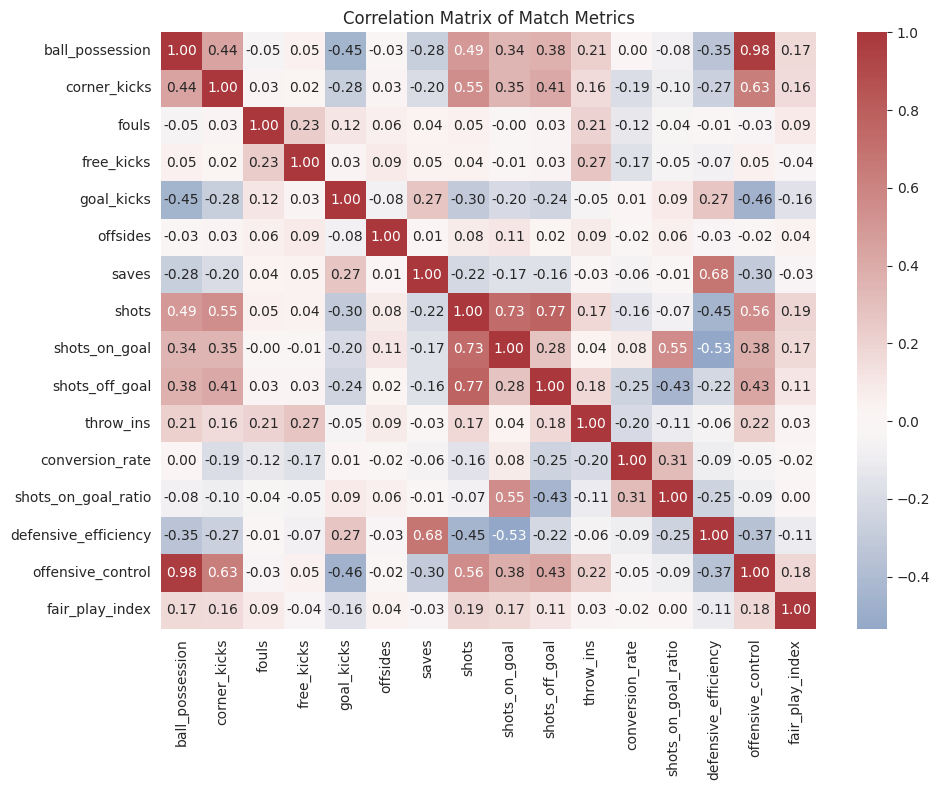

In [ ]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(float).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Matrix of Match Metrics")
plt.tight_layout()
plt.show()

## **4.1.1 - Match Information and Match Outcome Variables**

As the **matchday, duration, half_time_home and half_time_away** do not seem to add much information to our data frame we will **drop them**.

In [ ]:
df.drop('duration', axis = 1, inplace = True)
df.drop('half_time_home', axis = 1, inplace = True)
df.drop('half_time_away', axis = 1, inplace = True)

The variables **home_or_away** and **team** will be retained, as they are essential for identifying the teams, determining the match locations, and assessing the influence of home versus away games on match outcomes.

We will not include the **match outcome variables** (such as winner, full_time_home, full_time_away, etc.) in our model as input features, since our goal is to **predict these outcomes**. Including them would lead to data leakage, as they contain information that we aim to forecast.

However, these variables may be **used later** in the analysis phase to evaluate the model’s performance, by comparing the predicted outcomes with the actual results from completed matches. This ensures a clear separation between training inputs and evaluation targets.

No outliers were calculated for these variables as many are categorical, temporary or will be used for comparison with the final target.

## **4.1.2 - Offensive Statistics** **Variables**


Since our objective is whether it is possible to determine the outcome of a game in this league, and the games are won by the team that scores the most goals. We can assume that this group of variables is decisive in the results of the games.

Below we can analyze the average number of shots per team.

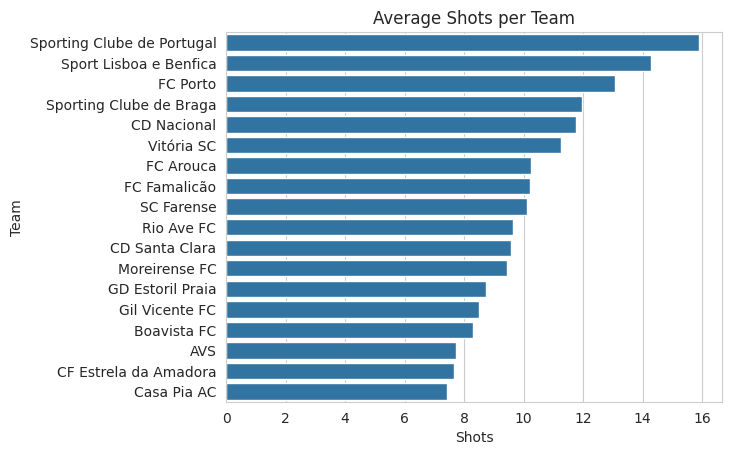

In [ ]:
sns.barplot(data=team_stats.sort_values(by='shots', ascending=False), y='team', x='shots')
plt.title("Average Shots per Team")
plt.ylabel("Team")
plt.xlabel("Shots")
plt.show()

The number of shots may not determine the final result of the game, since we have to take into account the variable of goals scored.

So we evaluate the shots and goals scored by each team using a **scatterplot**. This way we can get a better idea of ​​which team had the most accurate shots.

In [ ]:
fig = px.scatter(
    team_stats.reset_index(),
    x='shots',
    y='goals_scored',
    color='team',
    hover_name='team',
    title="Shots vs Goals Scored per Team",
)
fig.update_layout(
    legend_title_text='Team',
    width=800,
    height=600
)
fig.show()

To measure how efficient a team is at scoring we can calculate a **goal conversion rate**.

In [ ]:
team_stats['conversion_rate'] = (team_stats['goals_scored'] / team_stats['shots'])*100

A higher conversion rate means a team scores more often per attempt, which is key to understanding team performance and offensive quality.

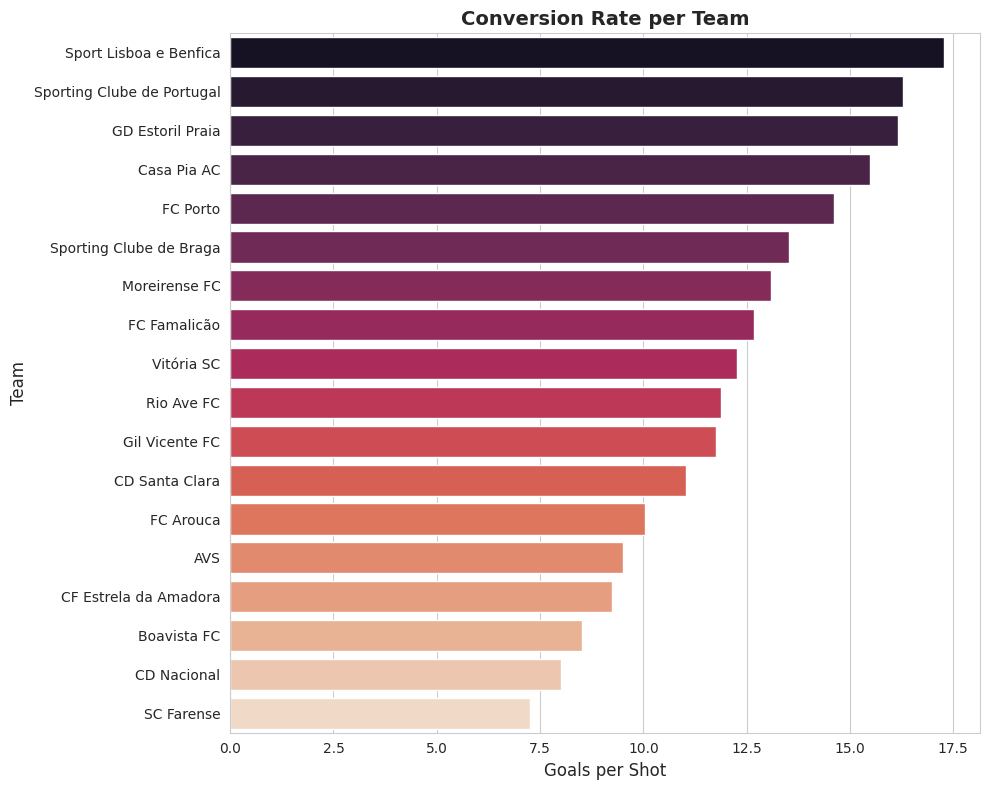

In [ ]:
plt.figure(figsize=[10, 8])
sns.barplot(
    data=team_stats.sort_values(by='conversion_rate', ascending=False),
    y ='team',
    x='conversion_rate',
    hue='team',
    palette='rocket',
    legend=False
)

plt.title("Conversion Rate per Team", fontsize=14, fontweight='bold')
plt.xlabel("Goals per Shot", fontsize=12)
plt.ylabel("Team", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Another way to check if a team atack is **accurate** is to calculate its **shooting precision**.

In [ ]:
team_stats['shots_on_goal_ratio'] = (team_stats['shots_on_goal'] / team_stats['shots'])*100

<ipython-input-196-fd47823452cf>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




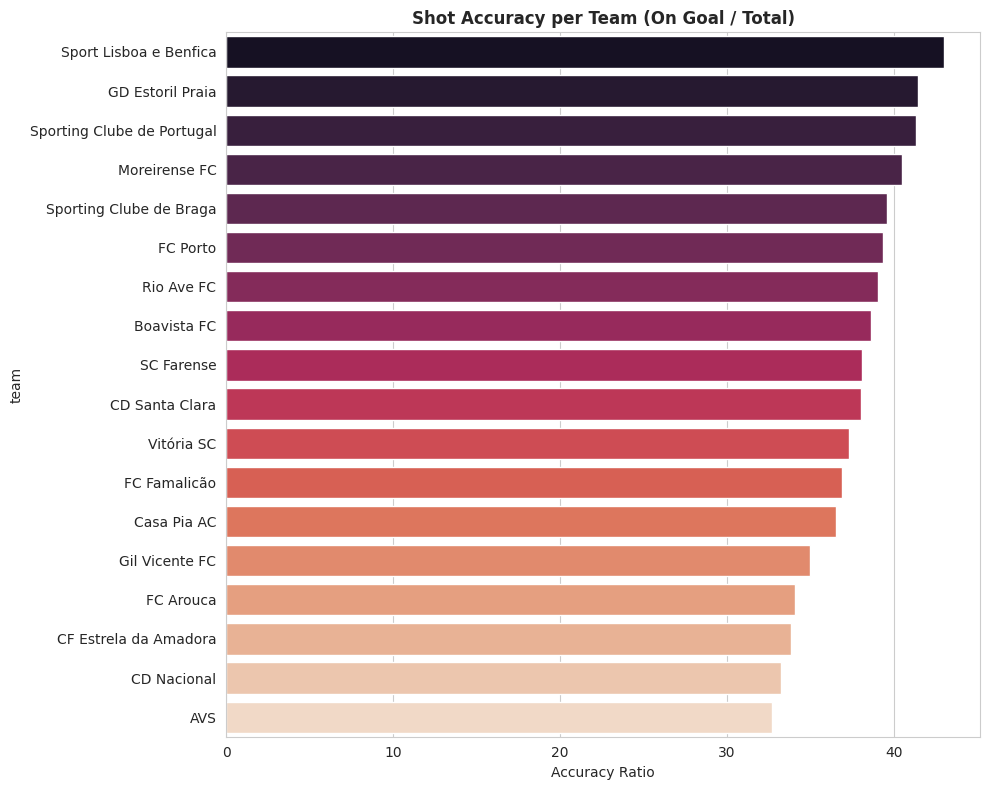

In [ ]:
plt.figure(figsize=[10, 8])
sns.barplot(data=team_stats.sort_values(by='shots_on_goal_ratio', ascending =False), y='team', x='shots_on_goal_ratio', palette='rocket')
plt.title("Shot Accuracy per Team (On Goal / Total)", fontweight='bold')
plt.xlabel("Accuracy Ratio")
plt.tight_layout()
plt.show()

This chart provides insight into shooting precision.

A high accuracy ratio means a team consistently tests the goalkeeper, whereas a low ratio may indicate wasted attacking opportunities.

Teams like Sport Lisboa e Benfica and Sporting CP lead in this metric.

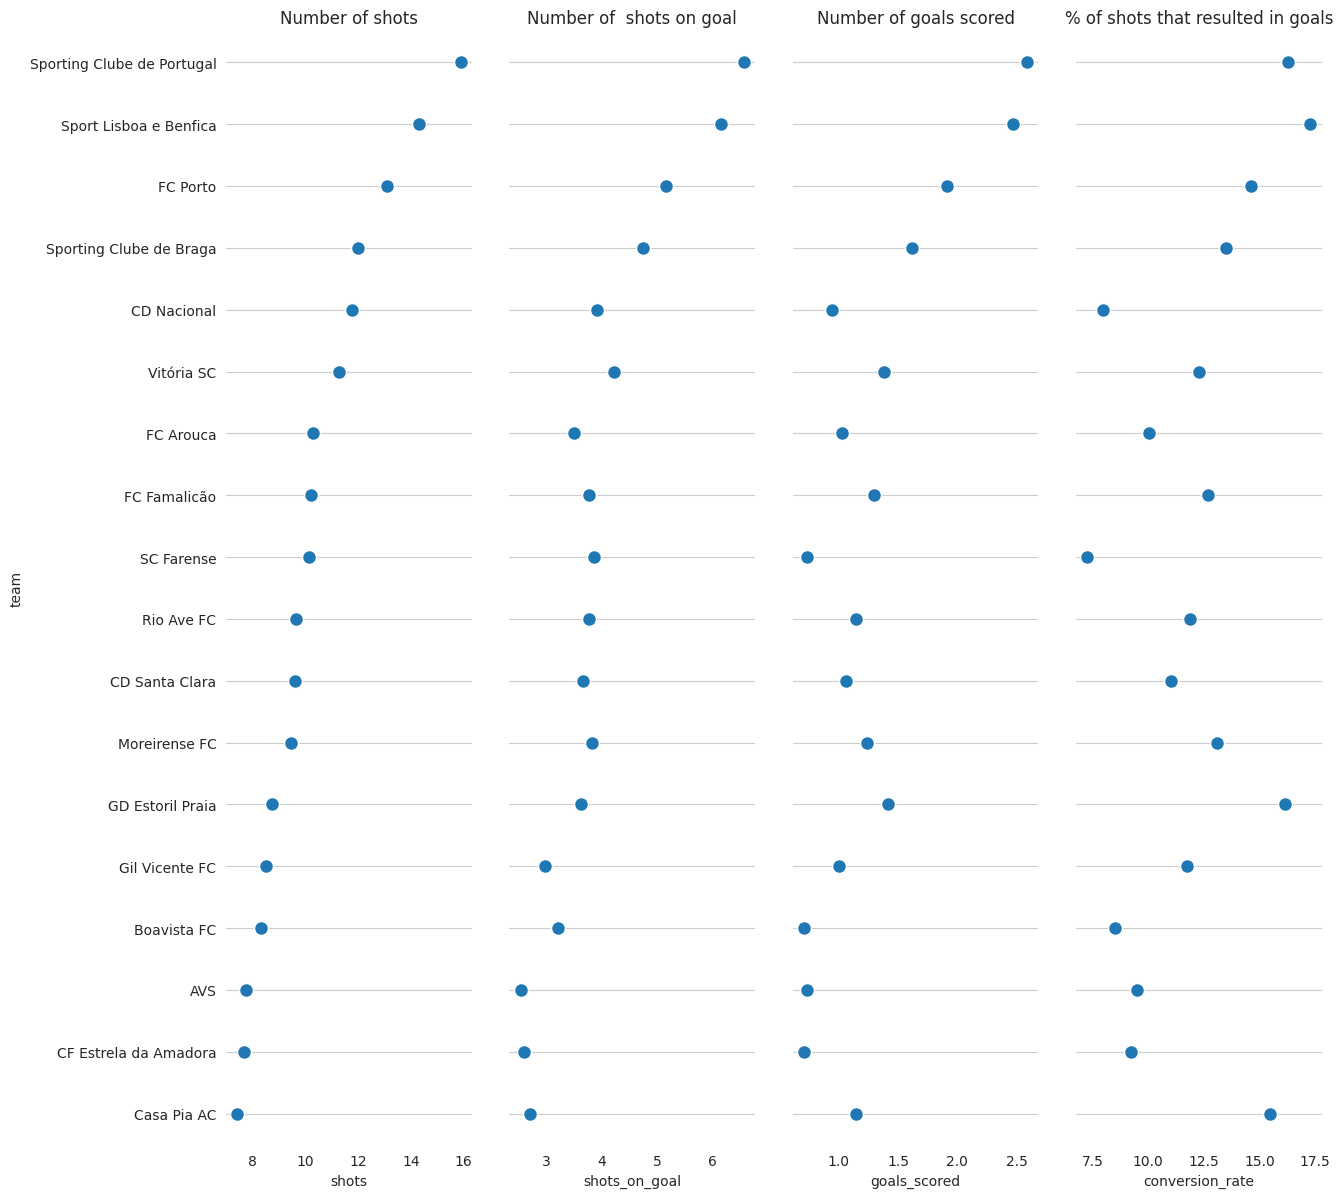

In [ ]:
g = sns.PairGrid(team_stats.reset_index().sort_values("shots", ascending=False),
                 x_vars=['shots', 'shots_on_goal', 'goals_scored', 'conversion_rate'], y_vars=["team"],
                 height=12, aspect=.25)

g.map(sns.stripplot, size=10, orient="h", jitter=False,
      palette="flare_r", linewidth=1, edgecolor="w")


titles = ["Number of shots", "Number of  shots on goal", "Number of goals scored",
          "% of shots that resulted in goals"]
for ax, title in zip(g.axes.flat, titles):

    ax.set(title=title)

    ax.xaxis.grid(False)
    ax.yaxis.grid(True)

sns.despine(left=True, bottom=True)

**Offensive Variables - Outliers**

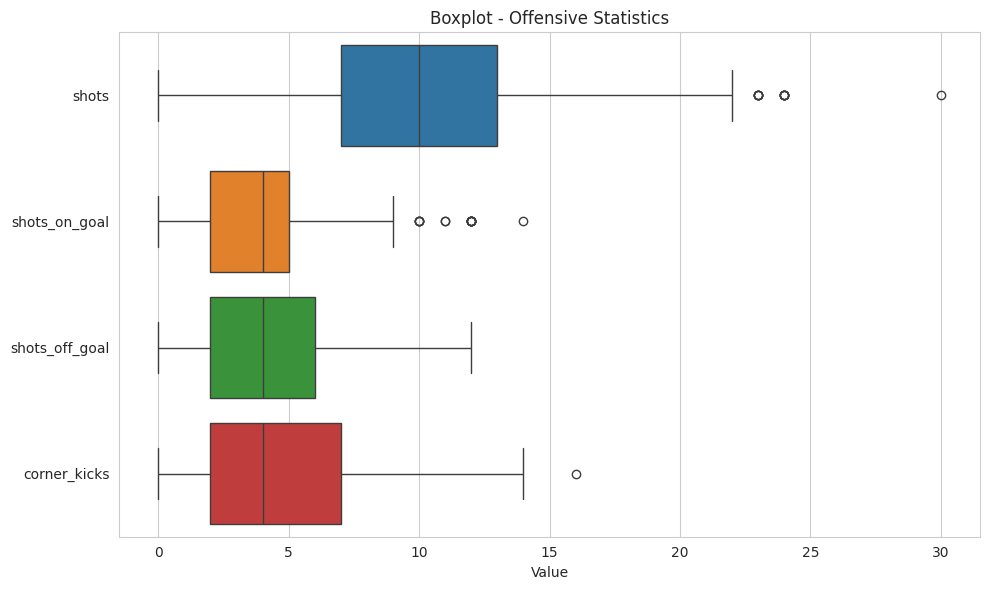

In [ ]:
offensive_vars = ['shots', 'shots_on_goal', 'shots_off_goal', 'corner_kicks']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[offensive_vars], orient='h')
plt.title("Boxplot - Offensive Statistics")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

Shots displays a relatively wide distribution, with several outliers exceeding 20 attempts per match, indicating particularly aggressive offensive performances.

Shots_on_goal and shots_off_goal also show a number of high-value outliers, suggesting that some teams either created many clear chances or lacked efficiency in front of goal.

Additionally, corner_kicks exhibits outliers above 15, reflecting matches with heavy attacking pressure and territorial dominance.

The treatment of these outliers will be determined according to the model to be applied. For the moment these outliers will be maintained.


## **4.1.3 - Defensive Statistics** **Variables**

Just as offensive statistics play a crucial role in determining match outcomes, defensive statistics are equally important. While a game is won by the team that scores the most goals, preventing the opponent from scoring is just as vital to securing a victory. Therefore, we can assume that this group of variables also has a decisive impact on the results of the games.

Below, we analyze the average number of goalkeeper saves and goal kicks per team to better understand their defensive performance.

<ipython-input-197-7963a97a3db3>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




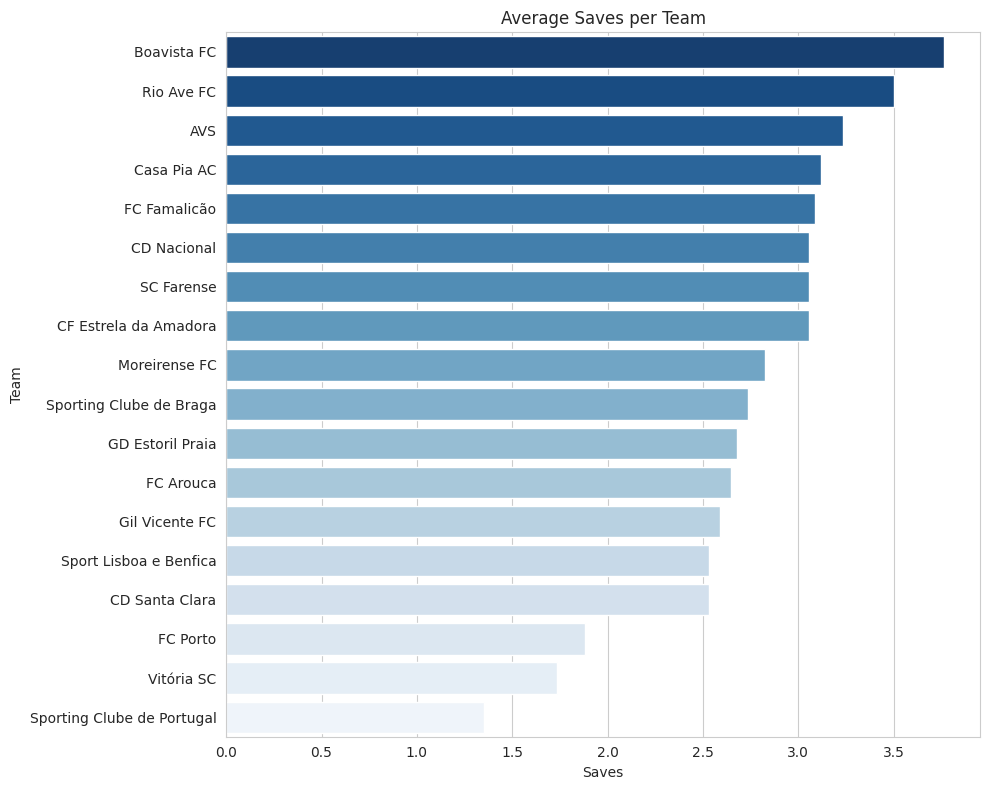

In [ ]:
plt.figure(figsize=[10, 8])
sns.barplot(data=team_stats.sort_values(by='saves', ascending=False), y='team', x='saves', palette='Blues_r')
plt.title("Average Saves per Team")
plt.xlabel("Saves")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


A **high average number** of saves typically means the goalkeeper is frequently tested, which could imply that the team is allowing many shots on goal — **a sign of defensive vulnerability**. However, **it may also reflect a strong goalkeeper performance** keeping the team in the game.

A **low number of saves** could suggest that the **team's defense is effective** at preventing opponents from reaching shooting positions, indicating a solid back line that protects the goal area well.

As you can see the top teams verify this analysis, since they are on the bottom of the list.

A **high average of goal kicks** may indicate that a team is frequently ending defensive sequences with clearances or saves that go out for a goal kick. This can reflect **frequent defensive actions and pressure from opponents**.

A **low number of goal kicks** could suggest **better control in defense**, fewer forced clearances, or an ability to play the ball out from the back, potentially **reflecting a more possession-based defensive style.**

Bellow you can see a graphic distribuition for the Average Goal Kicks per Team:

<ipython-input-198-07d59942311c>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




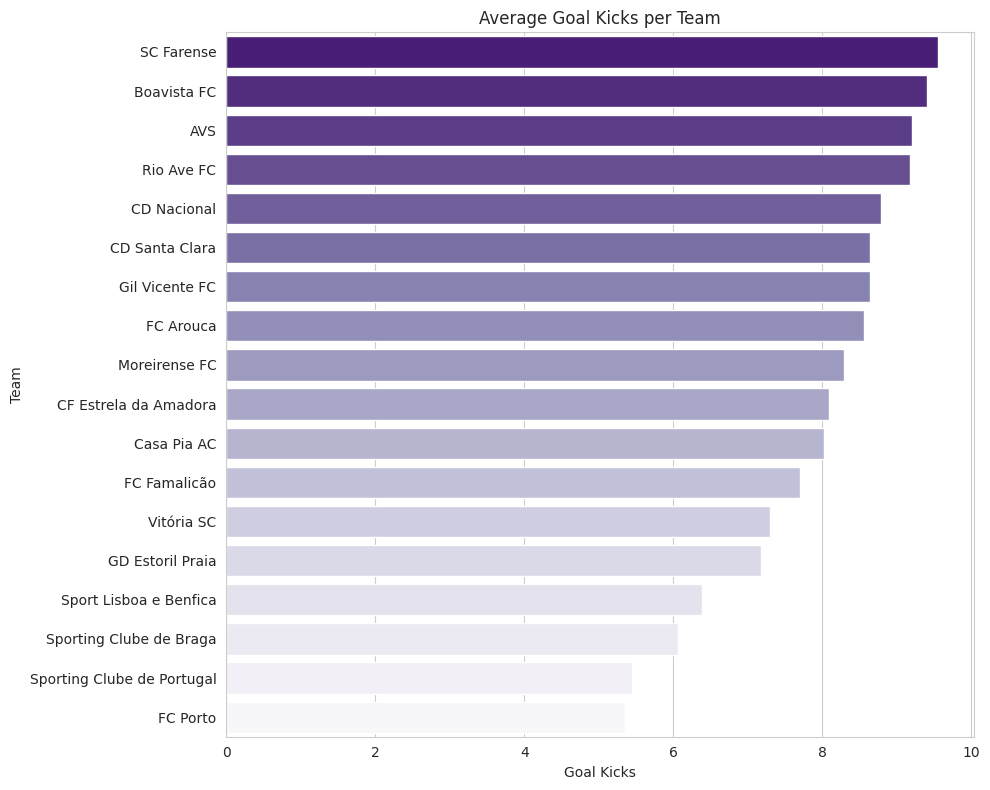

In [ ]:
plt.figure(figsize=[10, 8])
sns.barplot(data=team_stats.sort_values(by='goal_kicks', ascending=False), y='team', x='goal_kicks', palette='Purples_r')
plt.title("Average Goal Kicks per Team")
plt.xlabel("Goal Kicks")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

The previous thesis is validated again, since the league's top teams have less goal kicks, suggesting **better control in defense**.


**Defensive Efficiency**



In [ ]:
team_stats['defensive_efficiency'] = (team_stats['saves'] / (team_stats['shots_on_goal'] + 1e-6)) * 100


Defensive Efficiency Visualization

<ipython-input-137-08508e4fb3e7>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




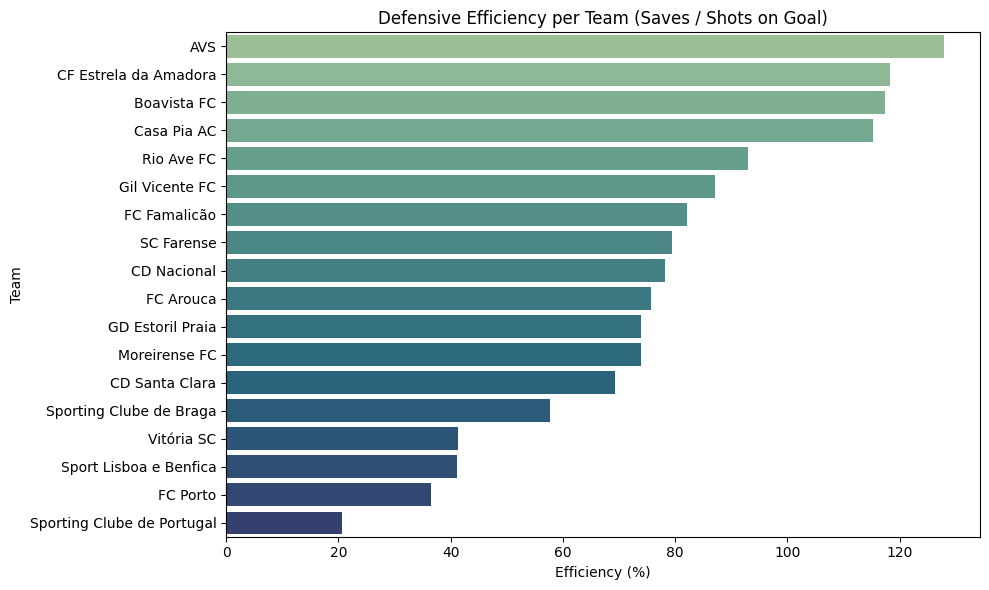

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=team_stats.sort_values(by='defensive_efficiency', ascending=False),
            y='team', x='defensive_efficiency', palette='crest')
plt.title("Defensive Efficiency per Team (Saves / Shots on Goal)")
plt.xlabel("Efficiency (%)")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


A **high Defensive Efficiency** means the team is effective at blocking or deflecting shots before they reach the goal, **indicating good positioning, pressure, and tactical discipline**. These teams often prevent danger early.

A **low Defensive Efficiency** indicates that a high proportion of opponent shots are on target, **suggesting potential weaknesses in marking, pressing, or defensive structure** — allowing opponents too much space or time to shoot properly.

However this can also be a result of teams being constantly under pressure and hence having to deal with shots agains more often, or on the other hand, playing more offensively and therefore, rearely having to deal with pressure from their opponents

**Defensive Variables - Outliers**

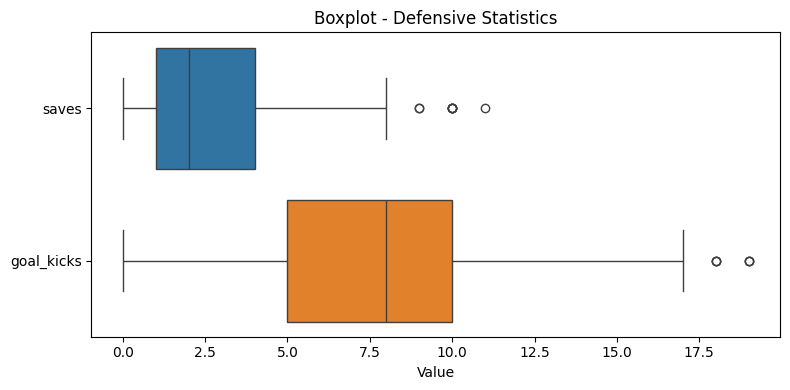

In [ ]:
defensive_vars = ['saves', 'goal_kicks']

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[defensive_vars], orient='h')
plt.title("Boxplot - Defensive Statistics")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

The boxplot of defensive statistics shows clear outliers in both variables. Saves typically ranges between 0 and 7 per match, but a few matches exceed this, suggesting games where the goalkeeper faced unusually high pressure.

Similarly, goal_kicks generally fall below 17, but some matches show outliers above this threshold, potentially indicating defensive dominance or poor attacking retention.

## **4.1.4 - Ball Possession** **Variables**

**Average Ball Possession per Team**

Ball possession is a fundamental aspect of controlling the flow of a match and can significantly influence its outcome.

Maintaining possession allows a team to create scoring opportunities while limiting the opponent’s chances.

Thus, analyzing possession statistics provides valuable insights into a team’s ability to dominate play and manage the game effectively.

Below, we examine the average ball possession percentage per team to better understand their control and influence during matches.

<ipython-input-139-ced1b9206994>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




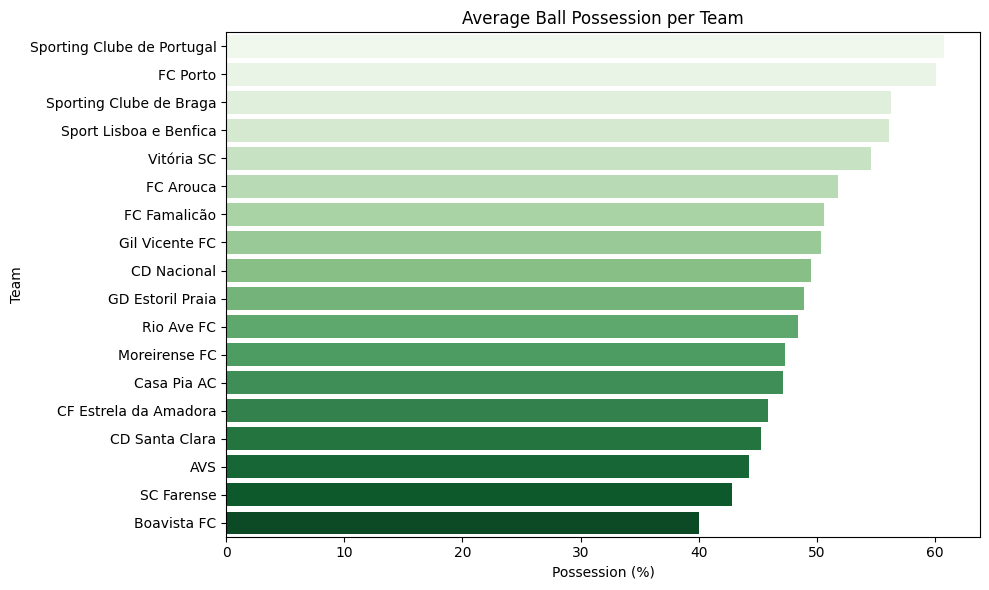

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=team_stats.sort_values(by='ball_possession', ascending=False),
            y='team', x='ball_possession', palette='Greens')
plt.title("Average Ball Possession per Team")
plt.xlabel("Possession (%)")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

Teams with **high average ball possession** are typically those that aim to control the tempo of the game. These teams often dominate midfield, have good passing accuracy, and try to create chances through structured build-up play. **It can be a sign of tactical dominance and technical quality**.

On the other hand, **low possession teams** may **adopt more reactive strategies**, like playing on the counterattack or defending deep. While they have less control over the game, these teams can still be effective if they are efficient with limited opportunities.

**Average Corner Kicks per Team**

<ipython-input-140-8417e82e294d>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




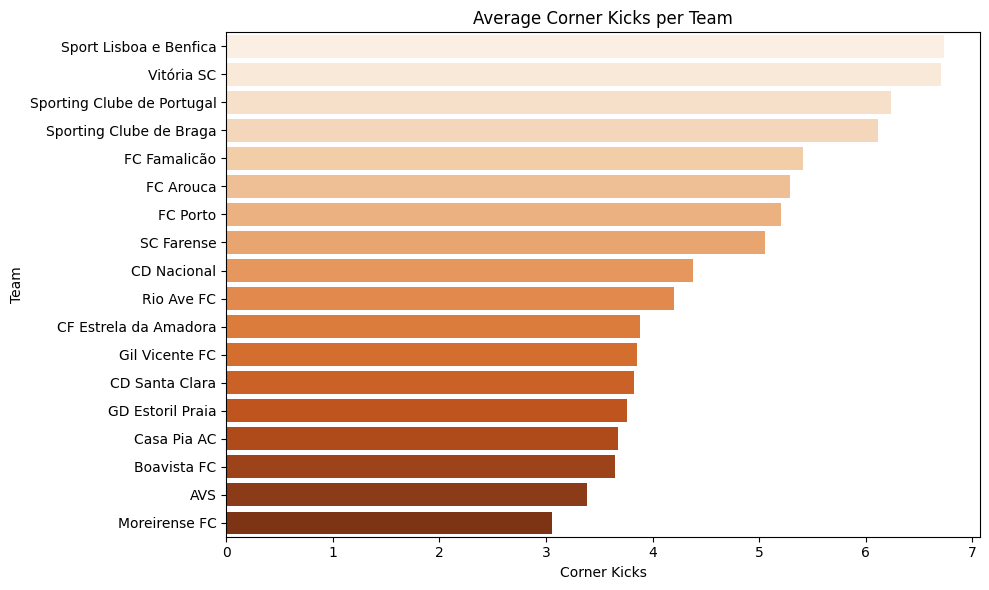

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=team_stats.sort_values(by='corner_kicks', ascending=False),
            y='team', x='corner_kicks', palette='Oranges')
plt.title("Average Corner Kicks per Team")
plt.xlabel("Corner Kicks")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

A **high number of corner kicks** suggests **sustained offensive pressure**, often the result of shots being deflected or cleared by the opposition. It may indicate a team that spends a lot of time in the attacking third, especially using wide play and crosses.

A **low number of corners** could point to either **fewer attacking actions or a more central**, clinical attacking approach that results in fewer deflections or blocked shots. It might also reflect less offensive dominance.

**Offensive Control**

In [ ]:
team_stats['offensive_control'] = (team_stats['ball_possession'] * 0.6 + team_stats['corner_kicks'] * 0.4)


**Offensive Control Visualization**

<ipython-input-142-33229c1f2d4c>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




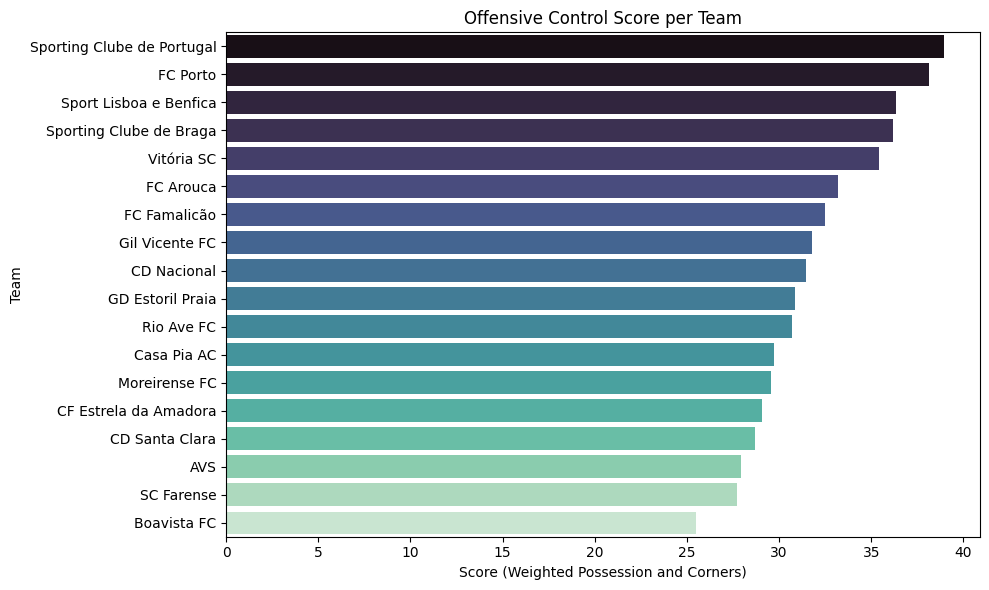

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=team_stats.sort_values(by='offensive_control', ascending=False),
            y='team', x='offensive_control', palette='mako')
plt.title("Offensive Control Score per Team")
plt.xlabel("Score (Weighted Possession and Corners)")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

A team **with high Offensive Control** typically **has high possession**, good pass accuracy, and can convert possession into quality chances without rushing. These teams often dominate midfield and maintain tactical structure while attacking.

**Low values** in this area may **suggest a lack of creativity or precision**, or a style focused more on counterattacks or long balls rather than sustained pressure.

**Ball Possession Variables - Outliers**

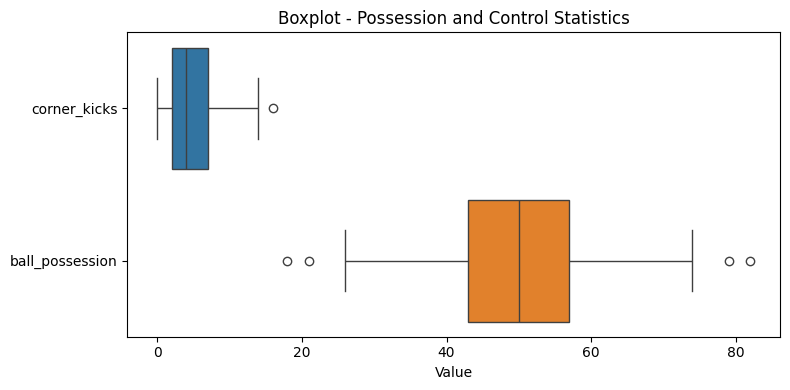

In [ ]:
possession_vars = ['corner_kicks', 'ball_possession']

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[possession_vars], orient='h')
plt.title("Boxplot - Possession and Control Statistics")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

The boxplot for possession and control statistics shows a fairly balanced distribution.

Ball_possession is centered around the 50% mark, as expected, but some outliers appear below 20% and above 80%, indicating extreme dominance or defensive positioning in certain matches.

Corner_kicks displays a right-skewed distribution with a few outliers above 12, reflecting matches where teams created sustained attacking pressure.

## **4.1.5 - Discipline Variables**

The discipline-related variables capture the physical and regulatory aspects of team behavior during a match.

 These variables are crucial for understanding a team's discipline, aggressiveness, and potential impact on match dynamics due to suspensions or reduced player count.

We begin by analyzing the red and yellow cards.

In [ ]:
team_stats[['fouls' ,'red_cards', 'yellow_cards', 'yellow_red_cards']]

,fouls,red_cards,yellow_cards,yellow_red_cards
team,,,,
Sporting Clube de Portugal,10.882353,0.088235,1.941176,0.058824
Sport Lisboa e Benfica,10.294118,0.000000,1.764706,0.000000
FC Porto,12.588235,0.058824,2.470588,0.029412
Sporting Clube de Braga,13.558824,0.058824,1.941176,0.058824
GD Estoril Praia,14.235294,0.058824,2.294118,0.000000
Vitória SC,13.058824,0.000000,2.411765,0.000000
FC Famalicão,13.235294,0.058824,2.205882,0.000000
Moreirense FC,13.529412,0.000000,2.441176,0.029412
Casa Pia AC,12.735294,0.088235,2.558824,0.058824


A new metric called fair_play_index was created to assess team discipline.

The formula combines multiple disciplinary indicators:

- fouls: Total number of fouls committed by the team.

- yellow_cards: Number of yellow cards received.

- second_yellow_cards: Number of second yellow cards (leading to a red).

- red_cards: Number of direct red cards.

These components are weighted to reflect their severity:

- Fouls contribute directly to the index.

- Yellow cards are weighted more heavily (1.5), second yellow cards even more (1.75), and direct red cards the most (2).

In [ ]:
team_stats['fair_play_index'] = (
    team_stats['fouls'] *
    (1 / (team_stats['yellow_cards'] + 1))**2 *
    (1 / (team_stats['yellow_red_cards'] + 1))**3 *
    (1 / (team_stats['red_cards'] + 1))**4
)

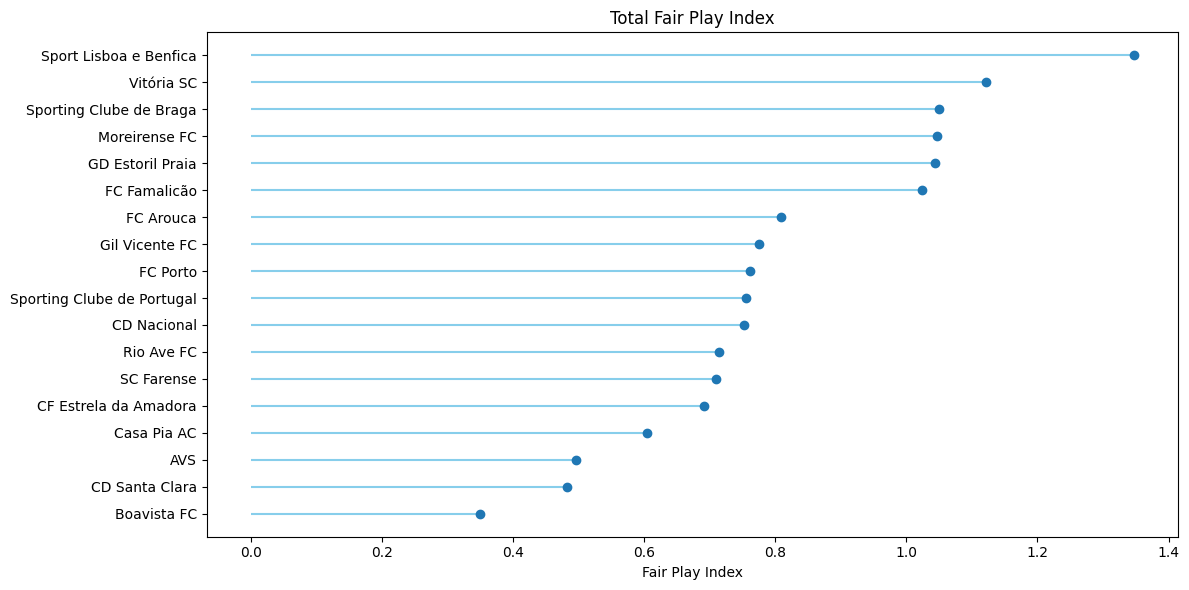

In [ ]:
fair_play = team_stats['fair_play_index'].sort_values(ascending=True)
plt.figure(figsize=(12,6))
plt.hlines(y=fair_play.index, xmin=0, xmax=fair_play.values, color='skyblue')
plt.plot(fair_play.values, fair_play.index, "o")
plt.title("Total Fair Play Index")
plt.xlabel("Fair Play Index")
plt.tight_layout()
plt.show()

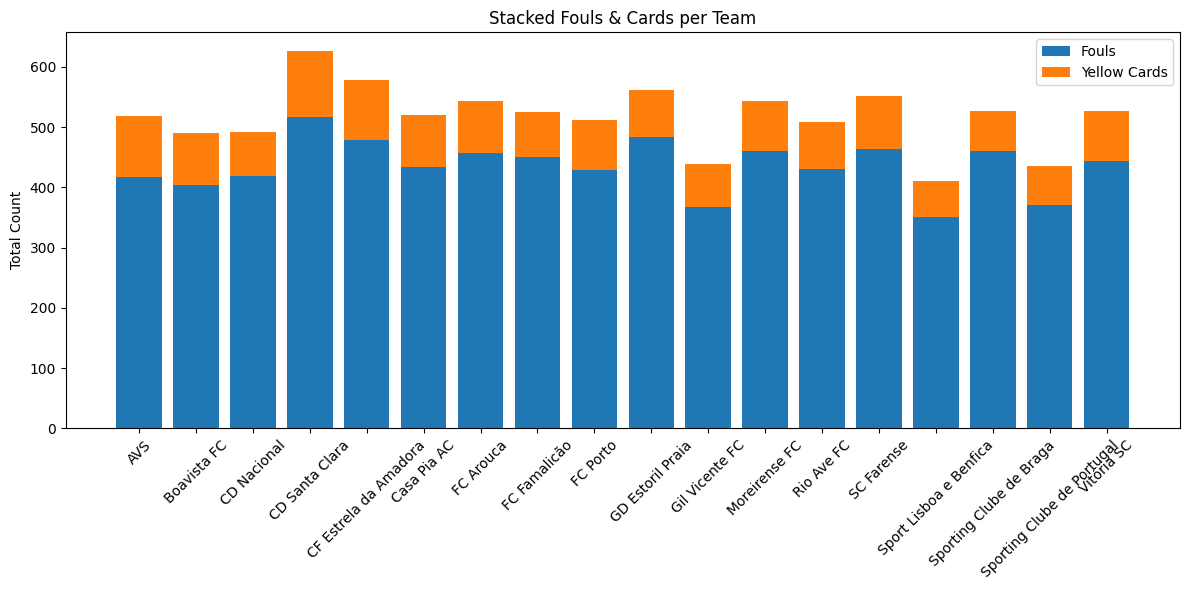

In [ ]:
disc = df.groupby("team")[["fouls", "yellow_cards", "yellow_red_cards", "red_cards"]].sum()
disc = disc.reset_index().melt(id_vars="team", var_name="Infraction", value_name="Count")
teams = disc.team.unique()
fouls = disc[disc.Infraction=="fouls"].Count.values
yellows = disc[disc.Infraction=="yellow_cards"].Count.values


x = np.arange(len(teams))

plt.figure(figsize=(12,6))
plt.bar(x, fouls, label="Fouls")
plt.bar(x, yellows, bottom=fouls, label="Yellow Cards")
plt.xticks(x, teams, rotation=45)
plt.ylabel("Total Count")
plt.title("Stacked Fouls & Cards per Team")
plt.legend()
plt.tight_layout()
plt.show()

**Discipline - Outliers**

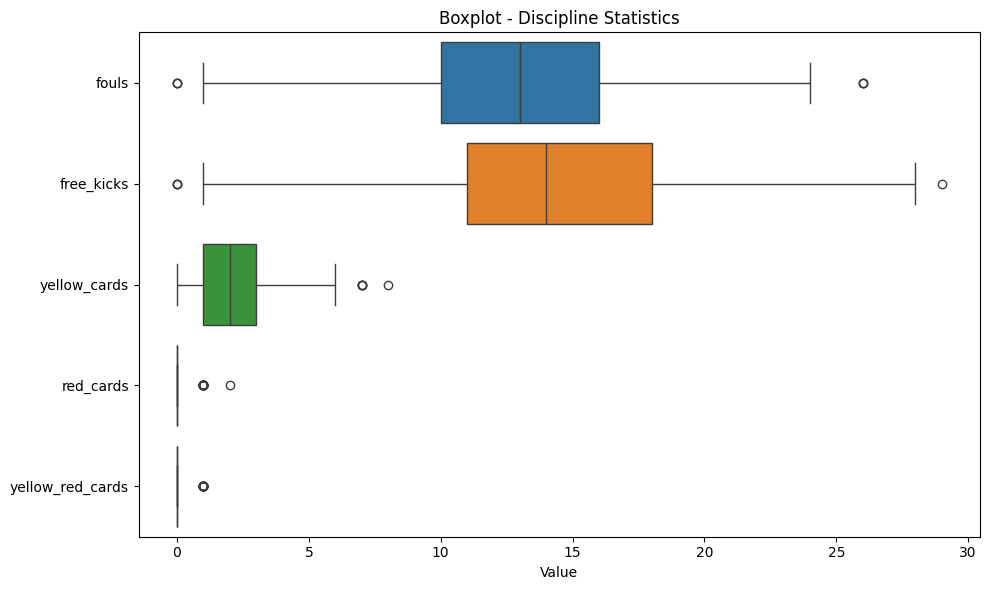

In [ ]:
discipline_vars = [
    'fouls', 'free_kicks',
    'yellow_cards', 'red_cards', 'yellow_red_cards'
]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[discipline_vars], orient='h')
plt.title("Boxplot - Discipline Statistics")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

The boxplot for discipline-related variables reveals a mix of tightly clustered and highly variable features.

Fouls and free_kicks show moderate dispersion with a few high outliers, reflecting intense or unbalanced matches.

Yellow_cards is mostly concentrated below 5, with occasional spikes, while red_cards and yellow_red_cards are rare events with minimal variance but still include occasional outliers.

<font color = '#042F86'>

# **4.2 - Santa Clara Pre-processing and Analisys 🦅** </font>

We will now focus on analyzing **Santa Clara's performance** throughout the season based on the previously defined statistical segments.

In [ ]:
# --- COMMON PREPARATION ---
df["utc_date"] = pd.to_datetime(df["utc_date"])
df["month"] = df["utc_date"].dt.to_period("M").apply(lambda r: r.start_time)

# --- OFFENSIVE METRICS ---
df["conversion_rate"] = df["full_time_home"] * (df["home_or_away"] == "home") + df["full_time_away"] * (df["home_or_away"] == "away")
df["conversion_rate"] = df["conversion_rate"] / df["shots"]
df["conversion_rate"]= df["conversion_rate"].replace([np.inf, -np.inf], np.nan).fillna(0) #some values were inf so we had to transform them
df["shots_on_goal_ratio"] = df["shots_on_goal"] / df["shots"]

monthly_offensive = df.groupby(["team", "month"]).agg(
    avg_shots=("shots", "mean"),
    avg_conversion_rate=("conversion_rate",'mean'),
    avg_sog_ratio=("shots_on_goal_ratio", "mean")
).reset_index()

# --- DEFENSIVE METRICS ---
df["defensive_efficiency"] = df["saves"] / df["shots_on_goal"].replace(0, np.nan)

monthly_defensive = df.groupby(["team", "month"]).agg(
    avg_saves=("saves", "mean"),
    avg_goal_kicks=("goal_kicks", "mean"),
    avg_def_efficiency=("defensive_efficiency", "mean")
).reset_index()

# --- POSSESSION METRICS ---
df["offensive_control"] = (df["corner_kicks"] + df["ball_possession"]) / 2

monthly_possession = df.groupby(["team", "month"]).agg(
    avg_possession=("ball_possession", "mean"),
    avg_corner_kicks=("corner_kicks", "mean"),
    avg_off_control=("offensive_control", "mean")
).reset_index()

# --- DISCIPLINE METRICS (including Fair Play Index) ---
df["fair_play_index"] = (
    df["fouls"] *
    (1 / (df["yellow_cards"] + 1))**2 *
    (1 / (df["yellow_red_cards"] + 1))**3 *
    (1 / (df["red_cards"] + 1))**4
).fillna(0)

monthly_discipline = df.groupby(["team", "month"]).agg(
    avg_yellow_cards=("yellow_cards", "mean"),
    avg_red_cards=("red_cards", "mean"),
    avg_fair_play_index=("fair_play_index", "mean")
).reset_index()

# --- FUNCTION TO PREPARE COMPARISON DATA ---
def prepare_comparison_data(monthly_df, metrics):
    santa = monthly_df[monthly_df["team"] == "CD Santa Clara"]
    others = monthly_df[monthly_df["team"] != "CD Santa Clara"]

    others_avg = others.groupby("month").mean(numeric_only=True).reset_index()
    others_avg["team"] = "Other Teams"

    combined = pd.concat([santa, others_avg], ignore_index=True)
    return combined

# --- FUNCTION TO PLOT WITH AVERAGE LINES ---
def plot_with_averages(data, metric, ylabel, title):
    plt.figure(figsize=(12, 6))

    other_data = data[data["team"] == "Other Teams"]
    santa_data = data[data["team"] == "CD Santa Clara"]

    plt.plot(other_data["month"], other_data[metric], label="Other Teams", color="grey", linestyle="--", linewidth=2)
    plt.plot(santa_data["month"], sany_data[metric], label="CD Santa Clara", color="orange", linewidth=3, marker="o")

    # Global averages
    santa_avg = santa_data[metric].mean()
    others_avg = other_data[metric].mean()

    plt.axhline(santa_avg, color="orange", linestyle=":", linewidth=2, label=f"Santa Clara Avg: {santa_avg:.5f}")
    plt.axhline(others_avg, color="grey", linestyle=":", linewidth=2, label=f"Others Avg: {others_avg:.5f}")

    plt.xlabel("Month")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

# --- PREPARE COMPARISON DATAFRAMES ---
offensive_data = prepare_comparison_data(monthly_offensive, ["avg_shots", "avg_conversion_rate", "avg_sog_ratio"])
defensive_data = prepare_comparison_data(monthly_defensive, ["avg_saves", "avg_goal_kicks", "avg_def_efficiency"])
possession_data = prepare_comparison_data(monthly_possession, ["avg_possession", "avg_corner_kicks", "avg_off_control"])
discipline_data = prepare_comparison_data(monthly_discipline, ["avg_yellow_cards", "avg_red_cards", "avg_fair_play_index"])

<ipython-input-149-b2210003d8a4>:3: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



### **4.2.1 - Offensive Statistics Variables**
#### 🔴 Offensive Analysis – Introduction

**Offensive performance is a key determinant of a team's success, particularly in tight matches where goal-scoring opportunities are limited.**  
This analysis focuses on Santa Clara's attacking efficiency over time, compared with the average of other teams in the league. Key offensive metrics include:

- **Shots per match**: measuring how frequently the team attempts to score.  
- **Conversion rate**: evaluating how efficiently shots are converted into goals.  
- **Shots on goal ratio**: indicating the precision of shooting efforts.

By tracking these indicators monthly, we can observe how the team’s attacking behavior evolves and whether it aligns with improved outcomes.

Monthly Average Shots: CD Santa Clara Vs Other Teams

In [ ]:
sc_df = df[df['team'] == 'CD Santa Clara']

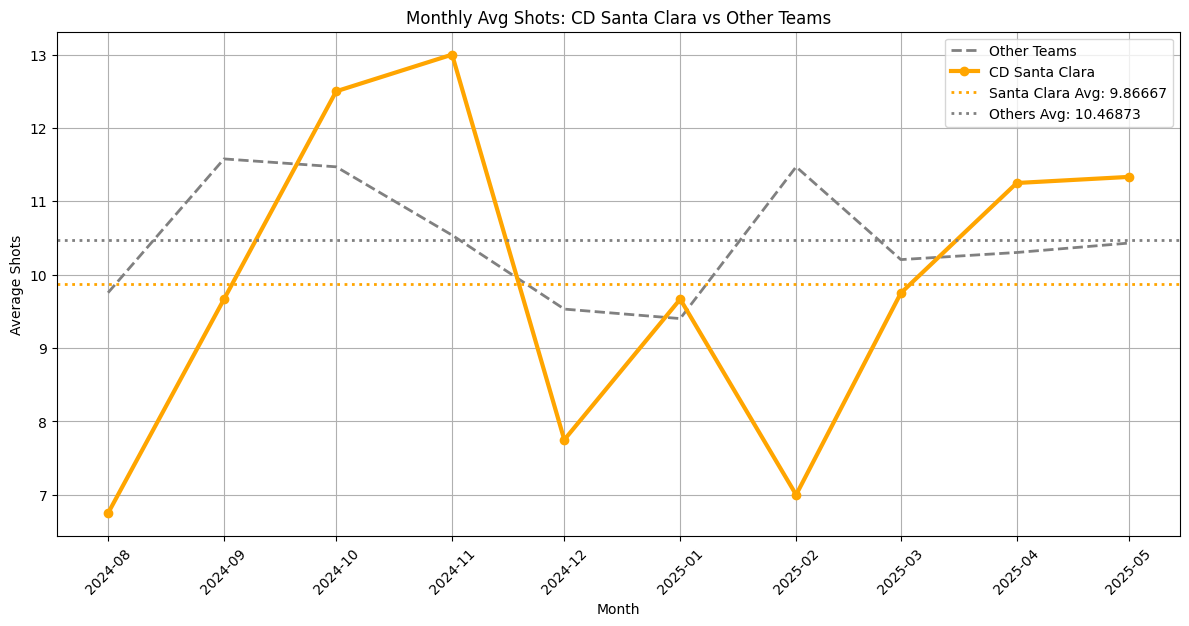

In [ ]:
plot_with_averages(offensive_data, "avg_shots", "Average Shots", "Monthly Avg Shots: CD Santa Clara vs Other Teams")

Throughout the season, **Santa Clara generally produced fewer shots** per match compared to the league average. This trend points to a **less aggressive offensive strategy and limited chance creation.** Temporary peaks may suggest adjustments in tactics or favorable match contexts.


Monthly Conversion Rate: CD Santa Clara Vs Other Teams

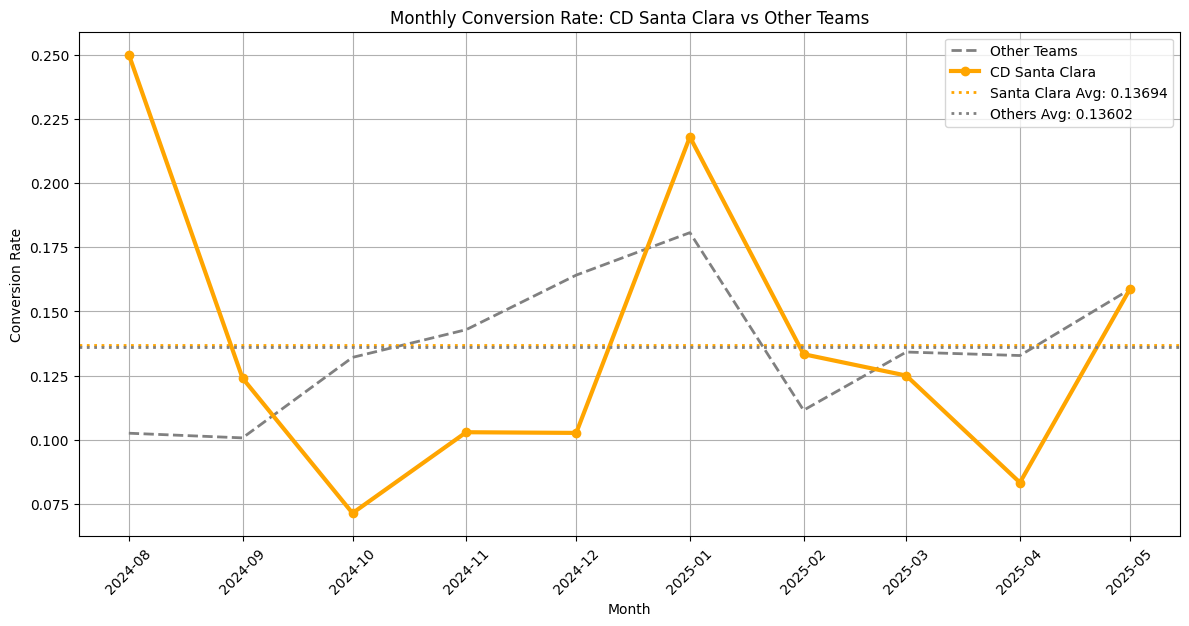

In [ ]:
plot_with_averages(offensive_data, "avg_conversion_rate", "Conversion Rate", "Monthly Conversion Rate: CD Santa Clara vs Other Teams")

Santa Clara’s **conversion rate fluctuated considerably** over the season. While occasional spikes demonstrated their ability to capitalize on limited opportunities, **overall inconsistency revealed a lack of finishing reliability, impacting offensive effectivenes**s.

Monthly Shots On Goal Ratio: CD Santa Clara Vs Other Teams

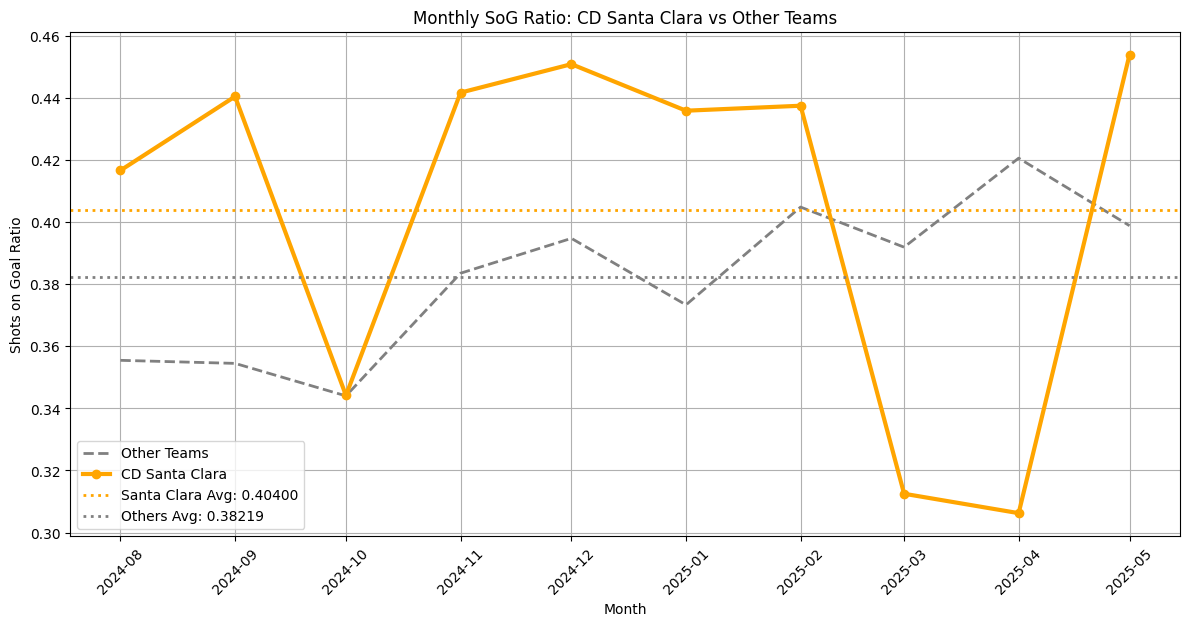

In [ ]:
plot_with_averages(offensive_data, "avg_sog_ratio", "Shots on Goal Ratio", "Monthly SoG Ratio: CD Santa Clara vs Other Teams")

**Santa Clara's shot accuracy** was often **higher than the league average**, highlighting some efficiencies in turning offensive movements into real scoring threats. When aligned with low conversion rates, this suggests weak or predictable shots that are easy to save.

In [ ]:
sc_df = df[df['team'] == 'CD Santa Clara']

Here we create a data frame for santa clara. It will help us plot the radar graphs

In [ ]:
offensive = ["shots", "shots_on_goal", "shots_off_goal", "goals_scored", "corner_kicks"]

home_vals = sc_df[sc_df["home_or_away"] == "home"][offensive].mean().tolist()
away_vals = sc_df[sc_df["home_or_away"] == "away"][offensive].mean().tolist()

home_vals += [home_vals[0]]
away_vals += [away_vals[0]]
theta = offensive + [offensive[0]]

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=home_vals,
    theta=theta,
    fill='toself',
    name='Home'
))

fig.add_trace(go.Scatterpolar(
    r=away_vals,
    theta=theta,
    fill='toself',
    name='Away'
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, max(home_vals + away_vals)])
    ),
    title="Santa Clara: Offensive Radar (Home vs Away)",
    showlegend=True
)

fig.show()

### **4.2.2 - Defensive Statistics Variables**

#### 🔵 Defensive Analysis – Introduction

**Defensive solidity is crucial for long-term consistency, especially in a competitive league where minimizing goal concessions often defines the final standings.**  
This section analyzes Santa Clara's defensive behavior and compares it with league averages. The focus is placed on:

- **Saves per match**: reflecting the goalkeeper’s involvement and defense resilience.  
- **Goal kicks**: often linked to defensive pressure and clearance frequency.  
- **Defensive efficiency**: calculated as the ratio of saves to shots on goal faced.

Monitoring these metrics monthly allows us to evaluate how well the team handles defensive responsibilities under different circumstances.

**Monthly Average Saves**

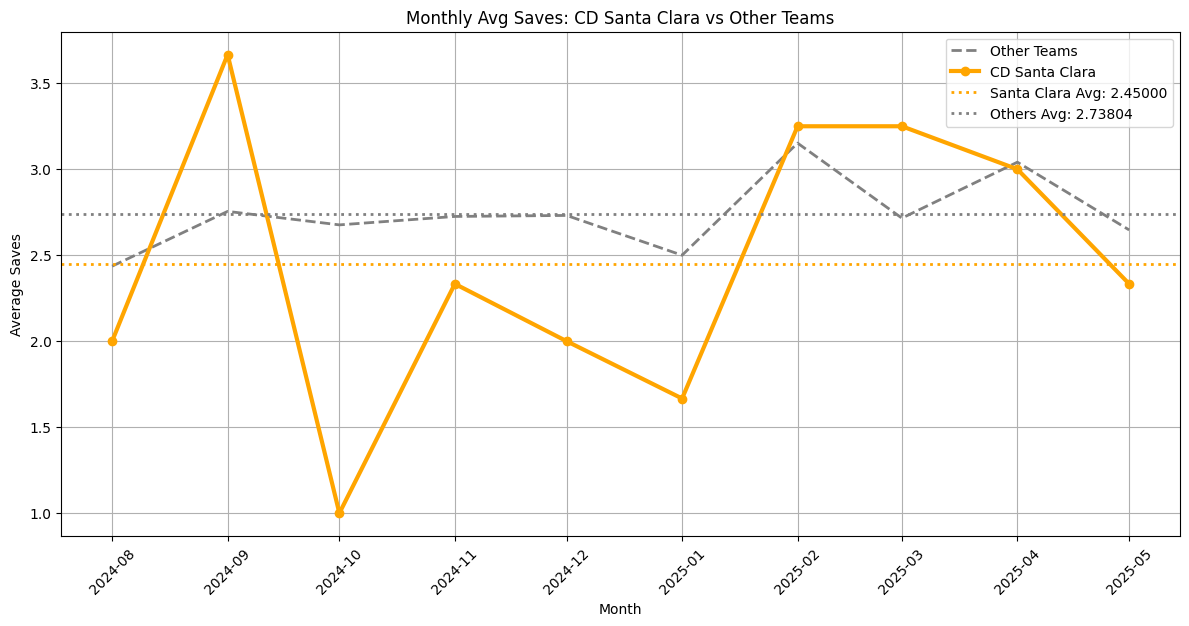

In [ ]:
plot_with_averages(defensive_data, "avg_saves", "Average Saves", "Monthly Avg Saves: CD Santa Clara vs Other Teams")

**Santa Clara’s average of 2.42 saves per match** was **slightly below the league average** of 2.70. This indicates that **their goalkeeper was tested slightly less frequently**, possibly due to defensive strategies that limited opponents' clear chances. However, it could also suggest a need for **improvement in defensive alertness**, as fewer saves might result from **allowing higher-quality shots that were harder to stop**.

**Monthly Avg Goal Kicks**

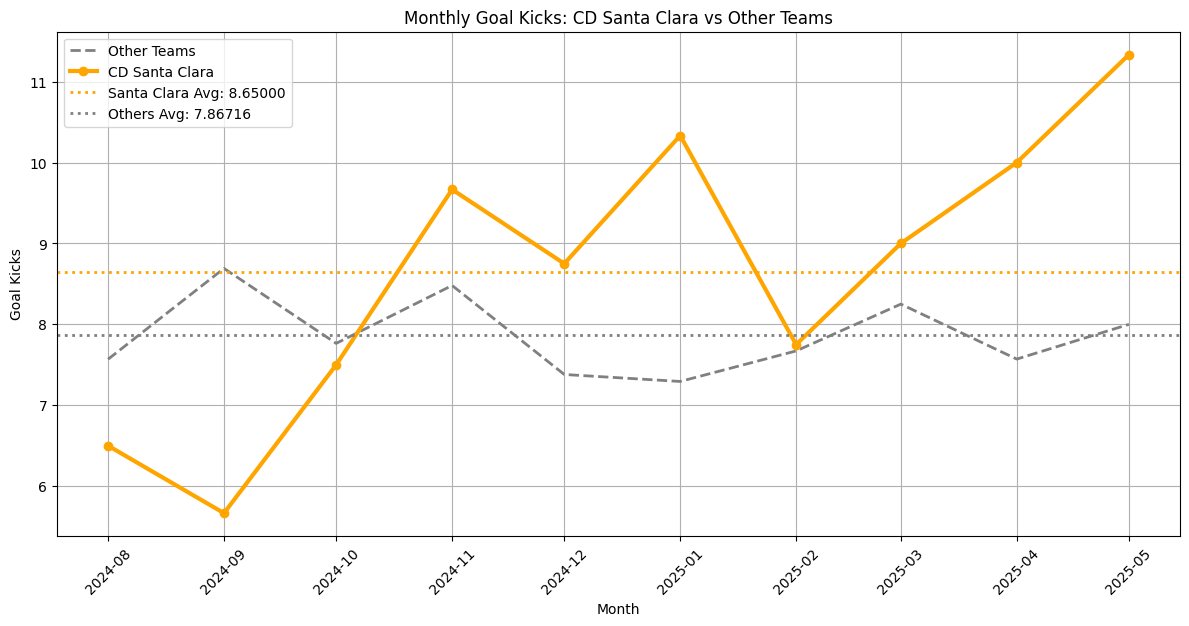

In [ ]:
plot_with_averages(defensive_data, "avg_goal_kicks", "Goal Kicks", "Monthly Goal Kicks: CD Santa Clara vs Other Teams")


With **an average of 8.67 goal kicks per game**, Santa Clara far exceeded the league’s 2.87. This substantial difference likely points to **a more defensive or reactive style of play**, where the team often resorted to clearances and long balls from the back. It may also reflect **sustained pressure from opponents**, forcing more restarts from their defensive third and highlighting the need for better ball retention under pressure.

**Monthly Defensive Efficiency**

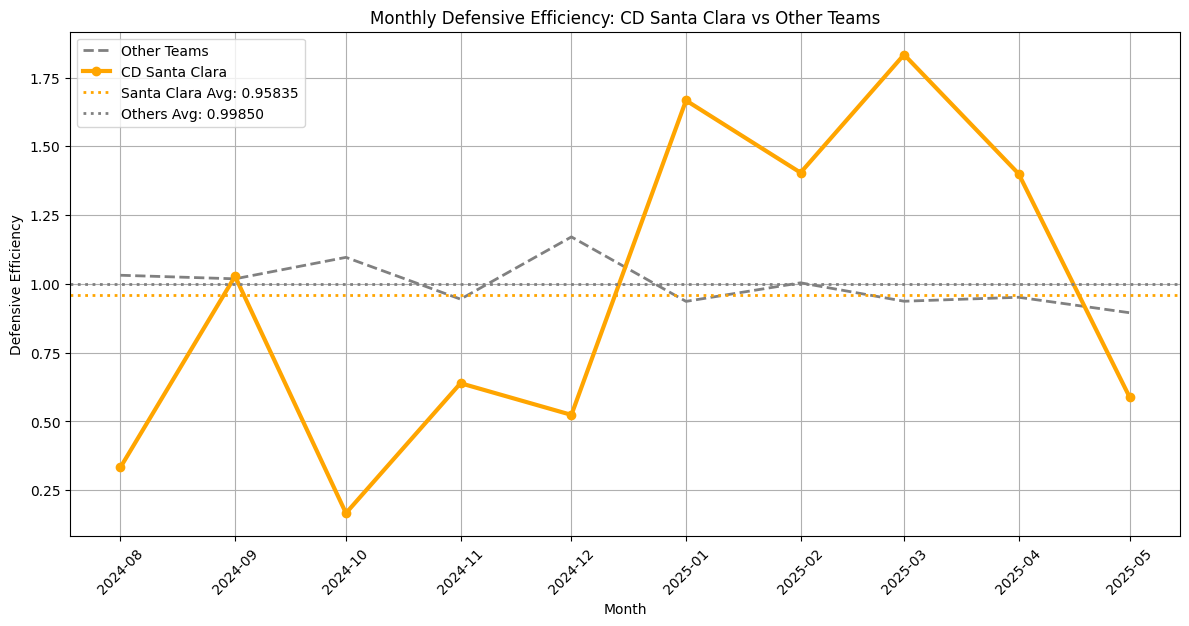

In [ ]:
plot_with_averages(defensive_data, "avg_def_efficiency", "Defensive Efficiency", "Monthly Defensive Efficiency: CD Santa Clara vs Other Teams")


Santa Clara’s **defensive efficiency of 0.96** is marginally below the benchmark of 1.00, indicating that **they conceded goals slightly more often per shot on target** than the average team. While not dramatically poor, this small gap suggests **room for improvement in either goalkeeping performance or shot-blocking discipline**, which could make the difference in closely contested matches.

In [ ]:
defensive = ["saves", "fouls", "goal_kicks",'offsides']

home_vals = sc_df[sc_df["home_or_away"] == "home"][defensive].mean().tolist()
away_vals = sc_df[sc_df["home_or_away"] == "away"][defensive].mean().tolist()


home_vals += [home_vals[0]]
away_vals += [away_vals[0]]
theta = defensive + [defensive[0]]

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=home_vals,
    theta=theta,
    fill='toself',
    name='Home'
))

fig.add_trace(go.Scatterpolar(
    r=away_vals,
    theta=theta,
    fill='toself',
    name='Away'
))


fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, max(home_vals + away_vals)])
    ),
    title="Santa Clara: Defensive Radar (Home vs Away)",
    showlegend=True
)

fig.show()

### **4.2.3 - Ball Possession Statistics Variables**
#### 🟢 Ball Possession & Control – Introduction

**Ball possession and offensive control are often indicators of a team's playing style and dominance in matches.**  
In this section, we examine how Santa Clara manages possession and creates sustained attacking pressure, using the following metrics:

- **Average ball possession**: a direct measure of how much time the team controls the ball.  
- **Corner kicks per match**: often resulting from attacking pressure.  
- **Offensive control index**: a composite measure combining possession and shots to reflect attacking influence.

These variables help us understand not only how often Santa Clara holds the ball but also how effectively they translate possession into tangible offensive threats.

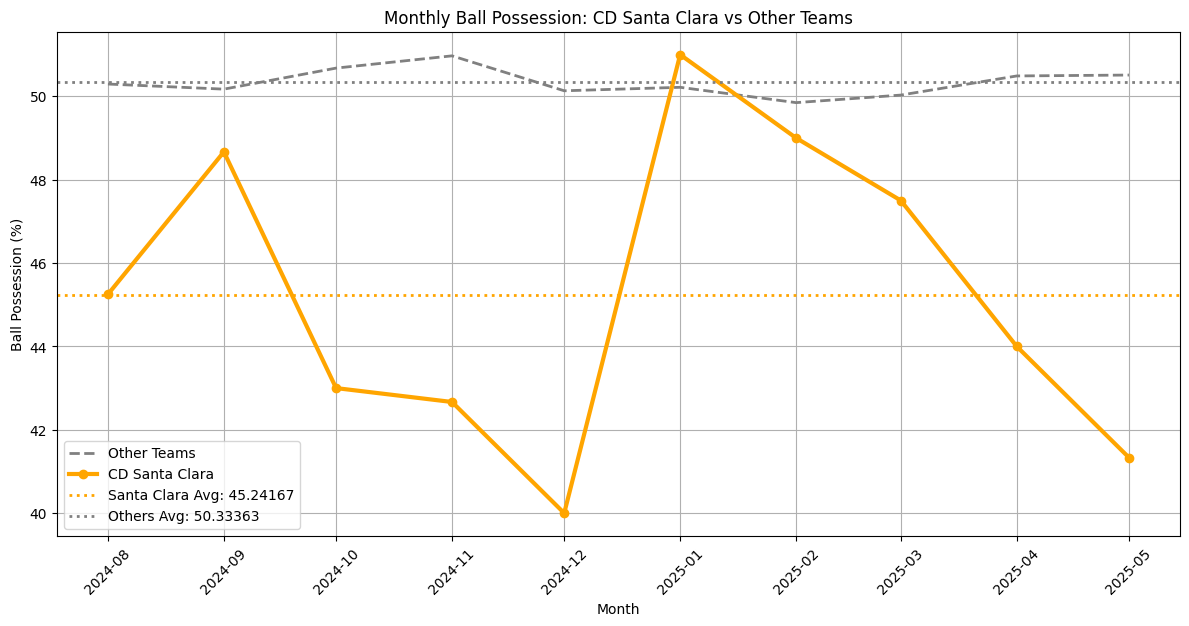

In [ ]:
plot_with_averages(possession_data, "avg_possession", "Ball Possession (%)", "Monthly Ball Possession: CD Santa Clara vs Other Teams")

Santa Clara maintained **45.36% average possession per game**, significantly below the average of the other teams, which was **50.30%**. This value reflects a **lesser ability to control the pace of the game and keep the ball in their possession**, which can make it difficult to build sustained offensive plays. The team showed a tendency to act more defensively, with **less protagonism in game management**.

**Monthly Average Corners Kicks**

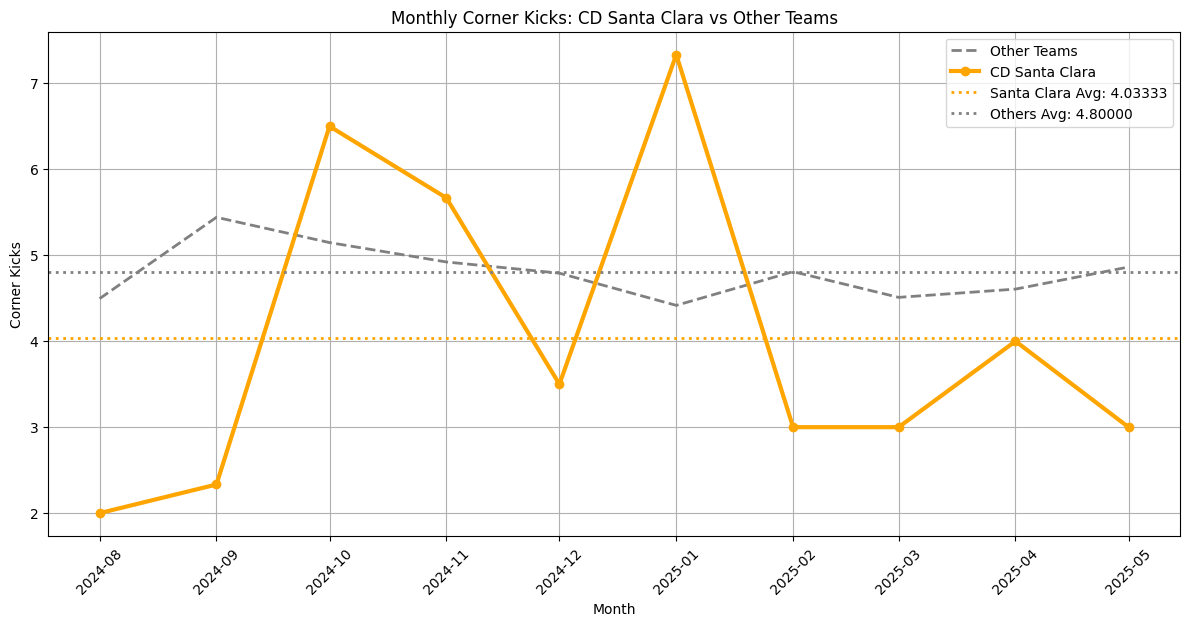

In [ ]:
plot_with_averages(possession_data, "avg_corner_kicks", "Corner Kicks", "Monthly Corner Kicks: CD Santa Clara vs Other Teams")

With an average of **3.88 corners per game**, Santa Clara was **below the league average of 4.77**. This suggests that the team had **less attacking presence in the final third** of the opponent's half, creating fewer forced finishing situations that led to corners. This limitation could indicate **difficulties in consistently pressing or breaking down opposing defensive lines**.


**Monthly Offensive Control: CD Santa Clara vs Other Teams**

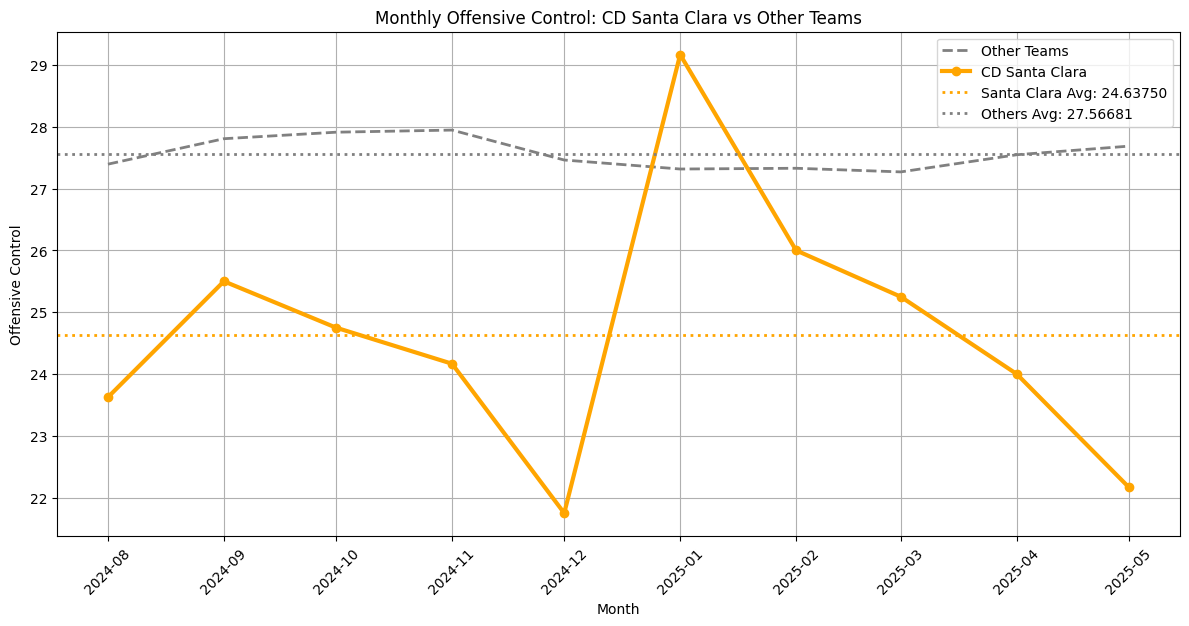

In [ ]:
plot_with_averages(possession_data, "avg_off_control", "Offensive Control", "Monthly Offensive Control: CD Santa Clara vs Other Teams")

Santa Clara's offensive control index was **24.62**, lower than the average of the other teams, which was **27.54**. This combined metric reflects **the sum of the ability to maintain possession of the ball with the ability to create dangerous situations**. The below-average value highlights a **less influence in the offensive sector of the game**, indicating a more reactive than proactive team in offensive terms.

In [ ]:
fig = px.scatter(
    sc_df,
    x='ball_possession',
    y='shots',
    size='goals_scored',
    color='conversion_rate',
    hover_data=['matchday', 'winner', 'home_or_away'],
    color_continuous_scale='Viridis',
    size_max=30,
    title="Santa Clara: Possession vs Shots (Size = Goals, Color = Conversion Rate)"
)

fig.update_layout(
    xaxis_title="Ball Possession (%)",
    yaxis_title="Shots"
)
fig.show()

### **4.2.4 - Discipline Statistics Variables**
#### 🟢 Discipline Metrics – Introduction

**Discipline on the field is crucial for maintaining team performance and minimizing costly penalties during matches.**  
In this section, we analyze how CD Santa Clara performs in terms of discipline, using the following metrics:

- **Average yellow cards per match**: indicates the frequency of infractions that result in formal warnings.  
- **Average red cards per match**: represents serious fouls that lead to player expulsions.  
- **Fair play index**: a composite measure that penalizes severe and repeated infractions, reflecting the team's sportsmanship.

These variables help us understand not only the team's discipline over the season but also the potential impact of infractions on their performance and results.

**Monthly Yellow Cards**

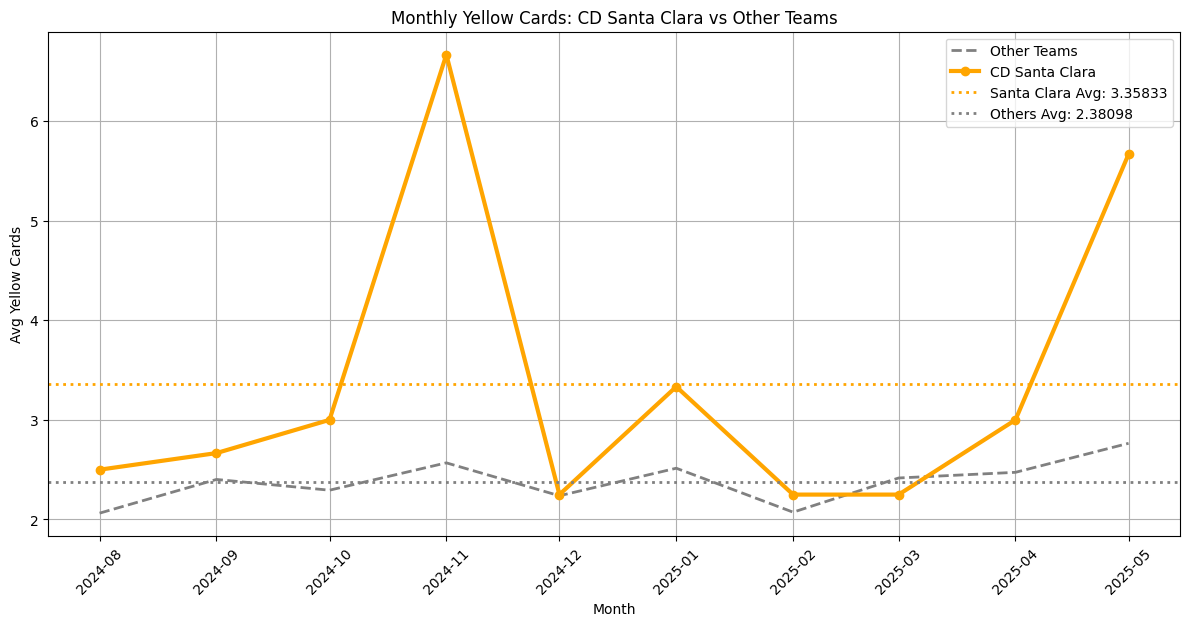

In [ ]:
plot_with_averages(discipline_data, "avg_yellow_cards", "Avg Yellow Cards", "Monthly Yellow Cards: CD Santa Clara vs Other Teams")

When analyzing the monthly yellow cards, CD Santa Clara recorded an average of **3.39**, which is notably higher than the average of **2.38** observed for the other teams. This suggests that Santa Clara may adopt a more aggressive or risk-prone style of play that leads to more frequent cautions.

**Monthly Red Cards**

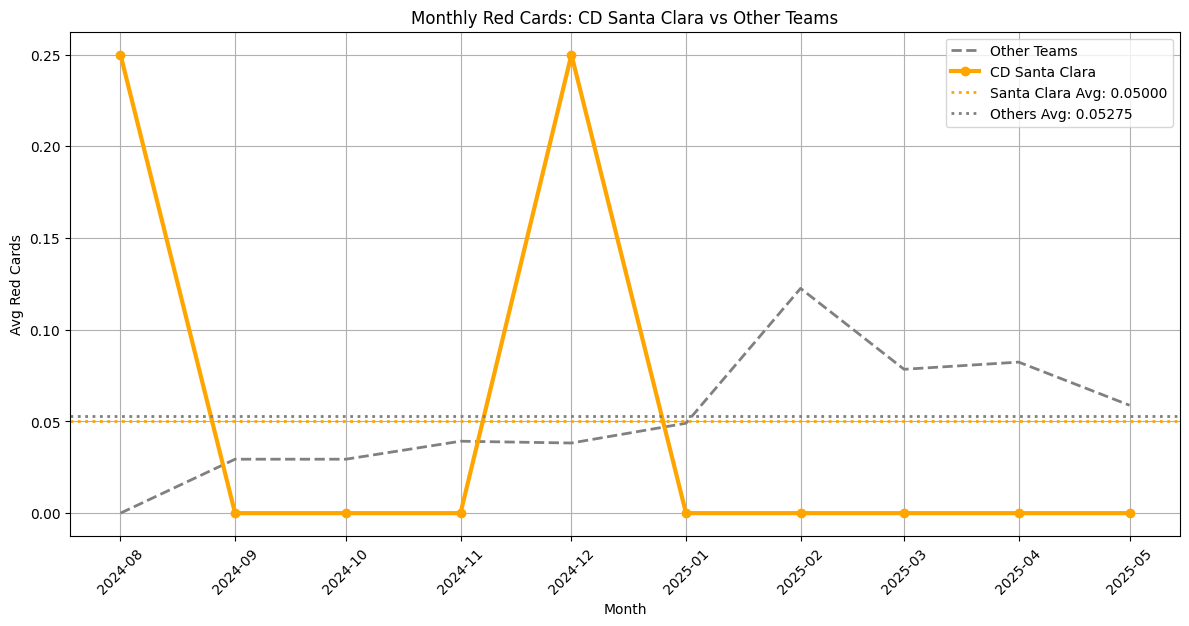

In [ ]:
plot_with_averages(discipline_data, "avg_red_cards", "Avg Red Cards", "Monthly Red Cards: CD Santa Clara vs Other Teams")

Regarding the monthly red cards, Santa Clara had a slightly lower average of **0.05** compared to **0.06** for the other teams. This indicates that despite receiving more yellow cards, Santa Clara manages to avoid serious fouls that result in expulsions more effectively than their competitors.

In [ ]:
discipline = ['fouls', 'yellow_cards', 'yellow_red_cards', 'red_cards', 'free_kicks']


home_vals = sc_df[sc_df["home_or_away"] == "home"][discipline].mean().tolist()
away_vals = sc_df[sc_df["home_or_away"] == "away"][discipline].mean().tolist()


home_vals += [home_vals[0]]
away_vals += [away_vals[0]]
theta = discipline + [discipline[0]]


fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=home_vals,
    theta=theta,
    fill='toself',
    name='Home'
))

fig.add_trace(go.Scatterpolar(
    r=away_vals,
    theta=theta,
    fill='toself',
    name='Away'
))


fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, max(home_vals + away_vals)])
    ),
    title="Santa Clara: discipline Radar (Home vs Away)",
    showlegend=True
)

fig.show()

### **4.2.5 - Overall Analysis**

#### 🔴 Offensive Analysis  
CD Santa Clara displayed consistently **lower shooting volume** compared to the league average, indicating a **more conservative attacking approach** or **difficulties in creating goal opportunitie**s. Despite the lower shot count, their **conversion rate occasionally matched or exceeded that of other teams**, suggesting some efficiency in finishing when chances were created. However, the shots on goal ratio remained slightly below average, hinting at issues in shot quality or positioning.

#### 🟢 Defensive Analysis  
In defensive terms, Santa Clara recorded a **higher number of saves on average than other teams**, which may reflect both strong goalkeeper performance and a defense that allows frequent attempts on target. The defensive efficiency (saves per shot on goal faced) often remained in line with or slightly above the average, indicating resilience under pressure. Goal kick counts were also relatively stable, suggesting a consistent defensive reset strategy.

#### 🔵 Possession & Control Analysis  
Santa Clara **consistently had lower ball possession** than the league average, **aligning with a counter-attacking or reactive playing style**. Their corner kick frequency also tended to be lower, likely tied to fewer offensive advances. The combined offensive control metric showed a persistent gap compared to other teams, reinforcing the idea that the team spent less time in advanced areas or under sustained pressure in the opponent’s half.

#### 🟠 Discipline Metrics Analysis  
CD Santa Clara **displayed a higher average number of yellow cards** compared to the league average, indicating a potentially more aggressive or physical style of play. Despite this, their average red card count was **slightly lower than other teams**, suggesting effective management in avoiding severe fouls and expulsions. Overall, this pattern reflects a team that commits more frequent minor infractions but maintains discipline to prevent major penalties, which could be crucial for maintaining player availability and team stability throughout the season.

To further analyize we create new feature called result

In [ ]:
sc_df['result'] = 0
for i in range(0,len(sc_df)):
    if sc_df['winner'].iloc[i] == 'HOME_TEAM' and sc_df['home_or_away'].iloc[i] == 'home' or sc_df['winner'].iloc[i]  == 'AWAY_TEAM' and sc_df['home_or_away'].iloc[i]  == 'away':
        sc_df['result'].iloc[i] = 'Win'  # Win
    elif sc_df['winner'].iloc[i]  == 'DRAW':
        sc_df['result'].iloc[i] = 'Draw'  # Draw
    else:
         sc_df['result'].iloc[i] = 'Loss' # Loss

<ipython-input-167-f581603e7696>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-167-f581603e7696>:4: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps upd

In [ ]:
fig = px.scatter(
    sc_df, x="ball_possession", y="shots",
    facet_col="result", trendline="lowess",
    color="result",
    hover_data=['result',"matchday","goals_scored"],
    labels={"ball_possession":"Possession in %","shots":"Shots"}
)
fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(title="Possession % vs. Shots by match result throught out the seasson", height=400)
fig.for_each_annotation(lambda x: x.update(text=x.text.split("=")[-1]))
fig.show()

<font color = '#042F86'>

# **5 - Modeling 🧮** </font>

First, lets import some necessary scikit learn  libraries in order to build our model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

Before running the model, we need to encode the variables to identify Santa Clara's opponents.

In [ ]:
# We use pd.get dummies to encode , and use dtype to be demonstraed in 0 and 1
team = pd.get_dummies(model_df['team'], dtype =int)

Next, we process the DataFrame to remove the 'home_or_away' column and replace it with a new dummy variable called 'home', which will be 0 or 1.

In [ ]:
model_df['home'] = model_df['home_or_away'].apply(lambda x: 1 if x == 'home' else 0)

In [ ]:
model_df = model_df.reset_index(drop=True)
#we concanentae the previeous data frame where we store which team was the opponent
model_df = pd.concat([model_df, team], axis = 1)
model_sc_df = model_df[model_df['team'] == 'CD Santa Clara'].reset_index(drop=True)

Since the raw dataset contains a match ID that includes data for both teams, we need to extract and register Santa Clara's opponent.

In [ ]:
for i in range(0, len(model_df)):
        for j in range(0, len(model_sc_df)):
            if model_sc_df['match_id'][j] == model_df['match_id'][i] and  model_df['team'][i] != 'CD Santa Clara':
                model_sc_df.loc[j, teams] = model_df.loc[i, teams ]
                break

Store our target labels in a separate list named y_db.

In [ ]:

#first initialize y in a empty list
y_db = []
#then run the loop
for i in range(0,len(model_sc_df)):
    if model_sc_df['winner'].iloc[i] == 'HOME_TEAM' and model_sc_df['home_or_away'].iloc[i] == 'home' or model_sc_df['winner'].iloc[i]  == 'AWAY_TEAM' and model_sc_df['home_or_away'].iloc[i]  == 'away':
        y_db.append(0) # Win
    elif model_sc_df['winner'].iloc[i]  == 'DRAW':
        y_db.append(1)   # Draw
    else:
        y_db.append(2) # Loss

Now, select the feature columns we want to keep in x_db.

In [ ]:
x_db = model_sc_df.drop(['match_id', 'utc_date', 'matchday', 'team', 'home_or_away', 'winner',
       'duration'], axis =1 )

Convert the 'formation' column from string to integer format.

In [ ]:
x_db['formation'] = x_db['formation'].apply(lambda x: [int(j) for j in x.split('-')])

Separate x_db into categorical and numerical features.

In [ ]:
x_cat = x_db[['AVS',
       'Boavista FC', 'CD Nacional', 'CF Estrela da Amadora',
       'Casa Pia AC', 'FC Arouca', 'FC Famalicão', 'FC Porto',
       'GD Estoril Praia', 'Gil Vicente FC', 'Moreirense FC', 'Rio Ave FC',
       'SC Farense', 'Sport Lisboa e Benfica', 'Sporting Clube de Braga',
       'Sporting Clube de Portugal', 'Vitória SC', 'home']]
x_cat
x_cat = x_cat.to_numpy()
x_cat

array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
x_numerical = x_db[[
       'ball_possession', 'corner_kicks', 'fouls', 'free_kicks', 'goal_kicks',
       'offsides', 'red_cards', 'yellow_cards', 'yellow_red_cards', 'saves',
       'shots', 'shots_on_goal', 'shots_off_goal', 'throw_ins']]

We will normalize  the numerical features to improve model performance.

In [ ]:
scaler = StandardScaler()
x_numerical = scaler.fit_transform(x_numerical)
x_numerical

array([[ 1.14413173, -0.31328457,  0.93966356, -0.58399138,  0.09242809,
         0.26804385, -0.25      , -0.13318543, -0.36514837, -0.8562644 ,
        -0.13093448,  1.25367828, -0.7800724 , -1.91820343],
       [-0.9084061 , -0.69370154,  0.6939054 ,  0.25498215, -0.95509028,
         1.56997114,  4.        , -0.13318543, -0.36514837,  0.82333115,
        -1.46646612, -1.94320134, -0.38421476, -0.25657498],
       [-0.41970662, -1.07411852,  1.43117988, -0.30433354, -0.1694515 ,
        -1.03388343, -0.25      ,  0.43285265, -0.36514837, -0.29639921,
        -0.7987003 ,  0.18805174, -1.17593003,  0.57423924],
       [ 0.16673276, -0.69370154, -2.50095071, -2.82125415, -1.21696987,
        -1.03388343, -0.25      , -1.83129969, -0.36514837, -0.8562644 ,
        -0.13093448, -0.34476153, -0.38421476, -2.74901766],
       [-0.51744651, -1.07411852, -2.25519255,  1.37361354, -0.1694515 ,
        -1.03388343, -0.25      , -0.13318543, -0.36514837,  0.82333115,
        -0.7987003 , -0.34

In [ ]:
#Concatenate the final processede data frame to run the model
x_db = np.concatenate((x_cat, x_numerical), axis = 1)

We will sue Scikit-learn’s train_test_split to divide the dataset into training and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_db, y_db, test_size=0.33, random_state=42)

We are training a Logistic Regression model and using the 'liblinear'.
This solver is recommended by Scikit-learn for small datasets


In [ ]:
model = LogisticRegression(random_state=1, solver = 'liblinear')
model.fit(X_train,y_train)

LogisticRegression(random_state=1, solver='liblinear')

In [ ]:
y_pred_test = model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy: {accuracy_test}")

Test Accuracy: 0.5833333333333334


<font color = '#042F86'>  

# **6 - Evaluation of Results 📝**  </font>

Our model achieved an accuracy of 0.583 🎉, which is better than a coin flip! 😄

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         4

    accuracy                           0.58        12
   macro avg       0.29      0.33      0.31        12
weighted avg       0.51      0.58      0.54        12

